# Imports

In [1]:
import numpy as np
import scipy

%matplotlib inline

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize, CenteredNorm, PowerNorm
from matplotlib.ticker import MaxNLocator

# from dustmaps.edenhofer2023 import Edenhofer2023Query

from plummer_sphere import PlummerSphere, get_1d_sampler

import sys
sys.path.append('../')
import utils

%matplotlib inline

/disk1/kalda/conda/py311jax_updated/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
plt.rcParams['figure.dpi'] = 120
plt.style.use('dark_background')

# Mock dataset with extinction-based selection function

This notebook generates a mock dataset using a Plummer sphere as the dynamical model, applying a mock 3D dust map to assign stellar extinctions, and then cutting stars that are fainter than some apparent magnitude threshold. 

## Plummer sphere model

First, we sample points from a unit Plummer sphere.

The Plummer sphere is a spherically symmetric, self-gravitating system. It has density
$$
  \rho \left( r \right) = \frac{3}{4 \pi} \left( 1 + r^2 \right)^{-\frac{5}{2}} \, ,
$$
which generates the gravitational potential
$$
  \Phi \left( r \right) = -\left( 1 + r^2 \right)^{-\frac{1}{2}} \, .
$$
There exists a simple distribution function with isotropic velocities that renders the system stationary. Begin with the specific energy of an individual particle:
$$
  E = \frac{1}{2} v^2 + \Phi \, .
$$
Then, the distribution function
$$
  f \left( E \right) \propto
  \begin{cases}
    \left( -E \right)^{\frac{7}{2}} \, , & E < 0 \\
    0 \, , & E > 0
  \end{cases}
$$
reduces to the above density (after integrating over velocity) and is stationary, since it only depends on a conserved quantity: the energy. Note that because the energy is always negative, all the particles are on bound orbits.
$$
  p \left( E \right) \\
  p \left( E \mid r \right)
$$

$$
  p \left( r \right) \propto r^2 \rho \left( r \right) \\
  p \left( v \mid r \right) \propto v^2 \left[ \left( 1 + r^2 \right)^{-\frac{1}{2}} + \frac{1}{2} v^2 \right]^{\frac{7}{2}}
$$

If we scale $r$ to $kr$ and total mass $M$ to $\mu R$, then 

In [3]:
import plummer_sphere

dustmap_fname='/home/kalda/storage/projects/deep-potential/scripts/plummer/data/plummer_sphere_selfn_dustmaps.npz'
plummer = plummer_sphere.PlummerSphereSelfn(
    k=5, gamma=10.233267079464884, r_max=8.0,
    dustmap_fname=dustmap_fname,
    dustmap_n_samples=1024*1024,
    M_mean=0.5, M_sigma=2, m_max=15.0
)
r_max = plummer.r_max

Estimating the normalization constant of the DF with 1048576 samples...
Estimated DF normalization constant: 4.818853855133057


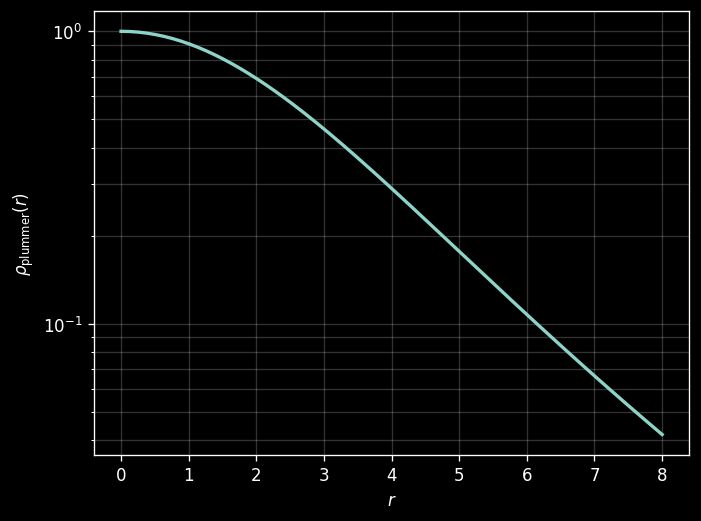

In [4]:
r = np.linspace(0, 8.0, 128)
rho_true = plummer.rho(r)
plt.plot(r, rho_true, lw=2)
#plt.ylim()
plt.xlabel('$r$')
plt.yscale('log')
plt.ylabel('$\\rho_\mathrm{plummer}(r)$')
plt.grid(which='both', alpha=0.2)
plt.show()

In [5]:
n_samples = 1024*1024*4
eta = plummer.sample_df(n_samples)
coords_train = utils.calc_coords(eta)

Acceptance rate: 0.2076


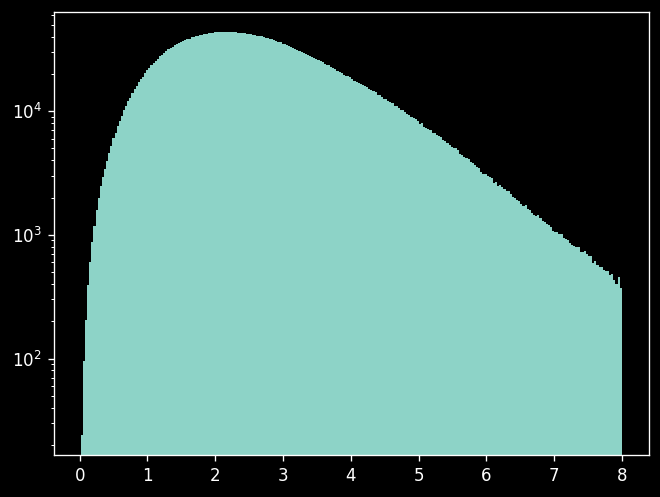

In [6]:
plt.hist(coords_train['r'], bins=256)
plt.yscale('log')
plt.show()

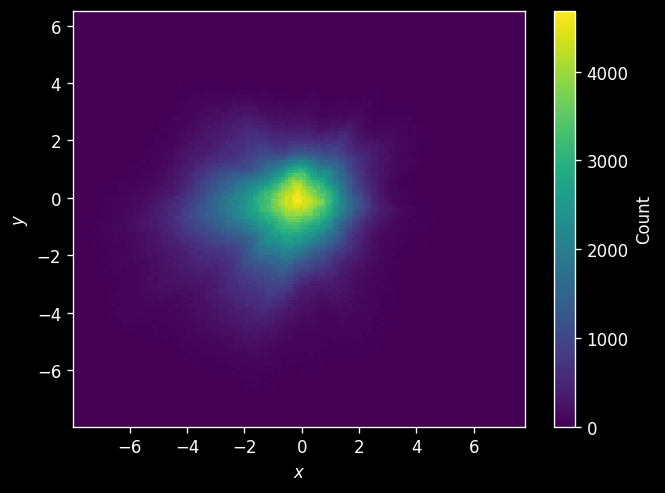

In [13]:
p_obs = plummer.p_obs(eta[:,:3])
r_max = plummer.r_max

# (x,y) projection of observation probability. Use hexbin.
fig, ax = plt.subplots(1, 1, figsize=(6,4), constrained_layout=True)
im = ax.hist2d(
    coords_train['x'], coords_train['y'],
    bins=128,
)[-1]
ax.set_aspect('equal')
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Count')
plt.show()

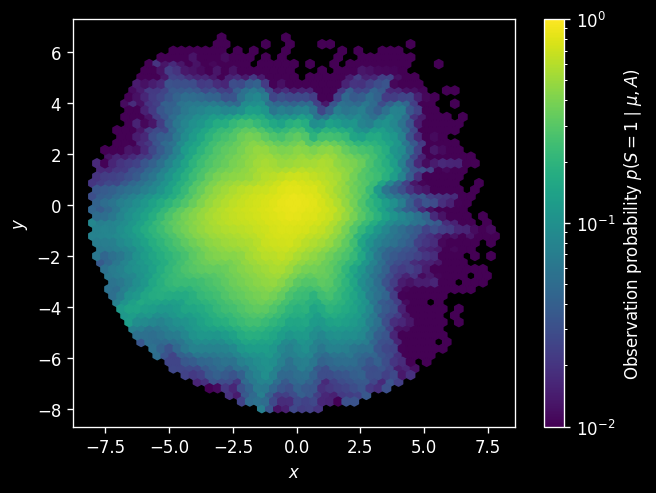

In [15]:
p_obs = plummer.p_obs(eta[:,:3])
r_max = plummer.r_max

# (x,y) projection of observation probability. Use hexbin.
fig, ax = plt.subplots(1, 1, figsize=(6,4), constrained_layout=True)
im = ax.hexbin(
    coords_train['x'], coords_train['y'],
    C=p_obs,
    gridsize=50,
    reduce_C_function=np.mean,
    # vmin=0, vmax=1,
    cmap='viridis',
    norm=LogNorm(vmin=1e-2, vmax=1)
)
ax.set_aspect('equal')
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
cbar = plt.colorbar(im, ax=ax)
cbar.set_label(r'Observation probability $p\left(S=1 \mid \mu, A\right)$')
plt.show()

In [ ]:
# Save a version of the dataset with only the stars that make the apparent magnitude cut
import h5py

weights = np.ones(len(eta), dtype='f4')
fn = 'plummer_sphere_obsstars_v5.h5'

kw = dict(compression='gzip', compression_opts=5, chunks=True)

with h5py.File(fn, 'w') as f:
    dset = f.create_dataset('eta', data=eta, **kw)
    dset.attrs['volume_type'] = 'sphere'
    dset.attrs['r_in'] = 0
    dset.attrs['r_out'] = r_max

    # Unit weights, even though selection is non-uniform
    f.create_dataset('weights', data=weights, **kw)

    # p(S=1 | mu, A) for each star that was observed. Can be used
    # to calculate weights.
    f.create_dataset('p_obs', data=p_obs.astype('f4'), **kw)

! du -sh {fn}
! h5ls -v {fn}


104M	plummer_sphere_obsstars_v4.h5


/disk1/kalda/conda/py311jax_updated/lib/python3.11/pty.py:89: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


Opened "plummer_sphere_obsstars_v4.h5" with sec2 driver.
eta                      Dataset {4194304/4194304, 6/6}
    Attribute: r_in scalar
        Type:      native long
    Attribute: r_out scalar
        Type:      native double
    Attribute: volume_type scalar
        Type:      variable-length null-terminated UTF-8 string
    Location:  1:800
    Links:     1
    Chunks:    {16384, 1} 65536 bytes
    Storage:   100663296 logical bytes, 93242031 allocated bytes, 107.96% utilization
    Filter-0:  deflate-1 OPT {5}
    Type:      native float
p_obs                    Dataset {4194304/4194304}
    Location:  1:92400892
    Links:     1
    Chunks:    {8192} 32768 bytes
    Storage:   16777216 logical bytes, 15170692 allocated bytes, 110.59% utilization
    Filter-0:  deflate-1 OPT {5}
    Type:      native float
weights                  Dataset {4194304/4194304}
    Location:  1:92349964
    Links:     1
    Chunks:    {8192} 32768 bytes
    Storage:   16777216 logical bytes, 29696 

In [17]:
def calculate_weights(p, p_target, max_weight=10, min_weight=0.1):
    # We cap the weight at max_weight with a smooth rolloff and cut the stars which have weight lower than min_weight
    inv_weight = p / p_target

    # Have a 10% long quadratic transition
    inv_cap = 1 / max_weight
    delta_inv_cap = 0.1 * inv_cap

    inv_weight[p / p_target < inv_cap - delta_inv_cap] = inv_cap
    idx = (inv_cap - delta_inv_cap <= p / p_target) & (
        p / p_target < inv_cap + delta_inv_cap
    )
    inv_weight[idx] = (
        (p / p_target)[idx] - inv_cap + delta_inv_cap
    ) ** 2 / 4 / delta_inv_cap + inv_cap
    weight = 1 / inv_weight

    # Reject stars with weight < min_weight
    idx = weight < min_weight
    reject_p = np.zeros(len(p))
    reject_p[idx] = 1 - weight[idx] / min_weight
    weight[idx] = min_weight
    rng = np.random.default_rng(42)
    reject_idx = rng.random(len(p)) < reject_p
    print(f"rejected {np.sum(reject_idx):.0f} sources out of {len(reject_idx)}")
    weight[reject_idx] = 0
    return weight

weights = calculate_weights(np.array(p_obs), p_target=np.ones_like(weights))

rejected 0 sources out of 4194304


In [18]:
# Save a version of the dataset with only the stars that make the apparent magnitude cut
import h5py

fn = 'data/plummer_sphere_obsstars_weighted_v5.h5'

kw = dict(compression='gzip', compression_opts=5, chunks=True)

with h5py.File(fn, 'w') as f:
    dset = f.create_dataset('eta', data=eta, **kw)
    dset.attrs['volume_type'] = 'sphere'
    dset.attrs['r_in'] = 0
    dset.attrs['r_out'] = r_max

    # Unit weights, even though selection is non-uniform
    f.create_dataset('weights', data=weights.astype('f4'), **kw)

    # p(S=1 | mu, A) for each star that was observed. Can be used
    # to calculate weights.
    f.create_dataset('p_obs', data=p_obs.astype('f4'), **kw)

! du -sh {fn}
! h5ls -v {fn}


118M	data/plummer_sphere_obsstars_weighted_v5.h5


/disk1/kalda/conda/py311jax_updated/lib/python3.11/pty.py:89: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


Opened "data/plummer_sphere_obsstars_weighted_v5.h5" with sec2 driver.
eta                      Dataset {4194304/4194304, 6/6}
    Attribute: r_in scalar
        Type:      native long
    Attribute: r_out scalar
        Type:      native double
    Attribute: volume_type scalar
        Type:      variable-length null-terminated UTF-8 string
    Location:  1:800
    Links:     1
    Chunks:    {16384, 1} 65536 bytes
    Storage:   100663296 logical bytes, 93250974 allocated bytes, 107.95% utilization
    Filter-0:  deflate-1 OPT {5}
    Type:      native float
p_obs                    Dataset {4194304/4194304}
    Location:  1:106932663
    Links:     1
    Chunks:    {8192} 32768 bytes
    Storage:   16777216 logical bytes, 14940363 allocated bytes, 112.29% utilization
    Filter-0:  deflate-1 OPT {5}
    Type:      native float
weights                  Dataset {4194304/4194304}
    Location:  1:92358683
    Links:     1
    Chunks:    {8192} 32768 bytes
    Storage:   16777216 logica

In [ ]:
plummer_nodust = plummer_sphere.PlummerSphereSelfn(
    k=10, gamma=10, r_max=8.0,
)
n_samples = 1024*1024*4
eta_nodust = plummer_nodust.sample_df(n_samples)
coords_train_nodust = utils.calc_coords(eta_nodust)
p_obs_nodust = plummer_nodust.p_obs(eta_nodust[:,:3])

Acceptance rate: 0.3333


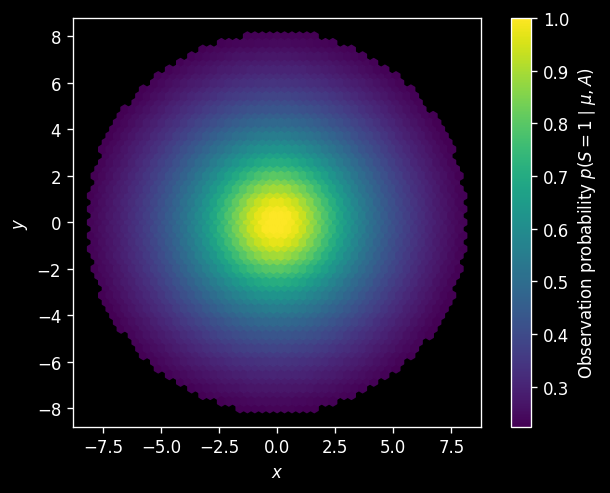

In [28]:
p_obs = plummer_nodust.p_obs(eta_nodust[:,:3])
r_max = plummer_nodust.r_max

# (x,y) projection of observation probability. Use hexbin.
fig, ax = plt.subplots(1, 1, figsize=(6,4), constrained_layout=True)
im = ax.hexbin(
    coords_train_nodust['x'], coords_train_nodust['y'],
    C=p_obs,
    gridsize=50,
    reduce_C_function=np.max,
    # vmin=0, vmax=1,
    cmap='viridis',
    # norm=LogNorm(vmin=1e-2, vmax=1)
)
ax.set_aspect('equal')
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
cbar = plt.colorbar(im, ax=ax)
cbar.set_label(r'Observation probability $p\left(S=1 \mid \mu, A\right)$')
plt.show()

In [29]:
# Save a version of the dataset with only the stars that make the apparent magnitude cut
import h5py

fn = 'plummer_sphere_obsstars_nodust_v4.h5'

kw = dict(compression='gzip', compression_opts=5, chunks=True)

with h5py.File(fn, 'w') as f:
    f.create_dataset('eta', data=eta_nodust, **kw)

    # Unit weights, even though selection is non-uniform
    f.create_dataset('weights', data=weights, **kw)

    # p(S=1 | mu, A) for each star that was observed. Can be used
    # to calculate weights.
    f.create_dataset('p_obs', data=p_obs_nodust.astype('f4'), **kw)

! du -sh {fn}
! h5ls -v {fn}


103M	plummer_sphere_obsstars_nodust_v4.h5


/disk1/kalda/conda/py311jax_updated/lib/python3.11/pty.py:89: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


Opened "plummer_sphere_obsstars_nodust_v4.h5" with sec2 driver.
eta                      Dataset {4194304/4194304, 6/6}
    Location:  1:800
    Links:     1
    Chunks:    {16384, 1} 65536 bytes
    Storage:   100663296 logical bytes, 93067041 allocated bytes, 108.16% utilization
    Filter-0:  deflate-1 OPT {5}
    Type:      native float
p_obs                    Dataset {4194304/4194304}
    Location:  1:93192617
    Links:     1
    Chunks:    {8192} 32768 bytes
    Storage:   16777216 logical bytes, 14609648 allocated bytes, 114.84% utilization
    Filter-0:  deflate-1 OPT {5}
    Type:      native float
weights                  Dataset {4194304/4194304}
    Location:  1:93141689
    Links:     1
    Chunks:    {8192} 32768 bytes
    Storage:   16777216 logical bytes, 29696 allocated bytes, 56496.55% utilization
    Filter-0:  deflate-1 OPT {5}
    Type:      native float


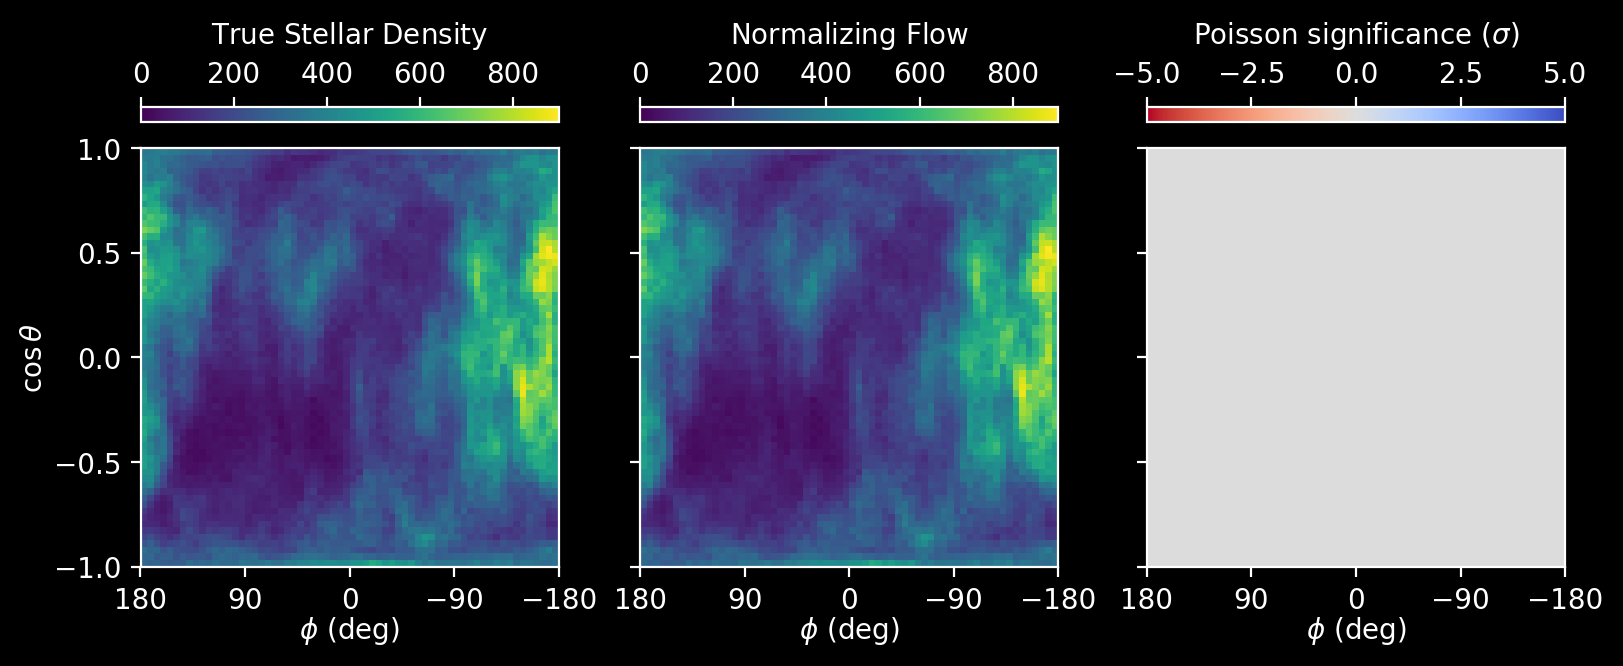

In [14]:
import matplotlib.colors as colors
import matplotlib.ticker as ticker

def plot_simple_2d_marginal(coords_sample, coords_train, weights_train, dim1, dim2, lims=None, cmap='viridis', logscale=False, fig_dir=None, fig_fmt=('png',)):
    labels = [
        '$R\mathrm{\ (kpc)}$', '$z\mathrm{\ (kpc)}$', r'cylindrical $\phi$ (deg)', '$v_R\mathrm{\ (km/s)}$', '$v_z\mathrm{\ (km/s)}$', r'$v_{\phi}\mathrm{\ (km/s)}$',
        '$x\mathrm{\ (kpc)}$', '$y\mathrm{\ (kpc)}$', '$z\mathrm{\ (kpc)}$', '$v_x\mathrm{\ (km/s)}$', '$v_y\mathrm{\ (km/s)}$', '$v_z\mathrm{\ (km/s)}$',
        '$r\mathrm{\ (kpc)}$', r'$\phi\mathrm{\ (deg)}$', r'$\cos \theta$', '$v_r\mathrm{\ (km/s)}$', r'$v_{\theta}\mathrm{\ (km/s)}$', r'$v_{\phi}\mathrm{\ (km/s)}$'
    ]
    keys = [
        'cylR', 'cylz', 'cylphi', 'cylvR', 'cylvz', 'cylvT',
        'x', 'y', 'z', 'vx', 'vy', 'vz',
        'r', 'phi', 'cth', 'vr', 'vth', 'vT'
    ]

    fig, all_axs = plt.subplots(
        2, 3,
        figsize=(8, 5),
        dpi=200,
        gridspec_kw=dict(width_ratios=[1,1,1], height_ratios=[0.1,3]),
        layout='compressed'
    )
    axs = all_axs[1,:]
    caxs = all_axs[0,:]

    def extract_dims(dim):
        coef = 100 if dim in ['cylvR', 'cylvz', 'cylvT', 'vx', 'vy', 'vz'] else 1
        if dim in ['phi']:
            coef = 180/np.pi
        if dim in ['cylvT']:
            coef *= -1

        return coef*coords_train[dim], coef*coords_sample[dim]

    x_train, x_sample = extract_dims(dim1)
    y_train, y_sample = extract_dims(dim2)
    labels = {k:l for k,l in zip(keys,labels)}

    if lims is None:
        # Take the 1th and 99th percentile
        lims = [
            [np.percentile(x_train, 1), np.percentile(x_train, 99)],
            [np.percentile(y_train, 1), np.percentile(y_train, 99)]
        ]
        k = 0.2
        for lim in lims:
            w = np.abs(lim[1] - lim[0]) * k
            lim[0] -= w
            lim[1] += w
        # Flip the x-axis if it's phi
        if dim1 == 'phi':
            # lims[0] = [lims[0][1], lims[0][0]]
            lims[0] = [180, -180]
        if dim2 == 'cth':
            lims[1] = [-1, 1]
    lims_ordered = [[np.min(lims[0]), np.max(lims[0])], [np.min(lims[1]), np.max(lims[1])]]
    kw = dict(range=lims_ordered, bins=64)

    n_train = len(x_train) if weights_train is None else np.sum(weights_train)
    n_sample = len(x_sample)

    if logscale:
        kw_col = dict(cmap=cmap, norm=colors.LogNorm(vmin=1, vmax=3000))
    else:
        kw_col = dict(cmap=cmap)

    #vmax = np.max(np.histogram2d(x_train, y_train, **kw)[0])
    vmax = None
    kw['rasterized'] = True
    nt, _, _, im = axs[0].hist2d(x_train, y_train, weights=weights_train, **kw, **kw_col, vmax=vmax, vmin=0)
    cb = fig.colorbar(im, cax=caxs[0], orientation='horizontal')
    cb.ax.xaxis.set_ticks_position('top')

    ns,_,_,im = axs[1].hist2d(x_sample, y_sample, **kw, **kw_col, weights=np.full(len(x_sample), n_train/n_sample), vmax=vmax, vmin=0)
    ns *= n_sample/n_train
    cb = fig.colorbar(im, cax=caxs[1], orientation='horizontal')
    cb.ax.xaxis.set_ticks_position('top')

    dn = ns/n_sample - nt/n_train
    with np.errstate(divide='ignore', invalid='ignore'):
        dn /= np.sqrt(ns * (n_train/n_sample)) / n_train
    vmax = 5.

    im = axs[2].imshow(
        dn.T,
        extent=lims_ordered[0]+lims_ordered[1],
        cmap='coolwarm_r',
        vmin=-vmax, vmax=vmax,
        origin='lower', aspect='auto',
        rasterized=True,
        interpolation='none'
    )
    cb = fig.colorbar(
        im, cax=caxs[2],
        orientation='horizontal'
    )
    cb.set_ticks([-5, -2.5, 0, 2.5, 5])
    cb.ax.xaxis.set_ticks_position('top')

    axs[1].set_yticklabels([])
    axs[2].set_yticklabels([])

    for ax in axs:
        ax.set_xlabel(labels[dim1], labelpad=0, fontsize=10)
        if dim1 == 'phi':
            ax.xaxis.set_major_locator(ticker.MultipleLocator(90))
        ax.set_box_aspect(1)

    axs[0].set_ylabel(labels[dim2], labelpad=2, fontsize=10)

    caxs[0].set_title(r'$\mathrm{True\ Stellar\ Density}$', fontsize=10)
    caxs[1].set_title(r'$\mathrm{Normalizing\ Flow}$', fontsize=10)
    caxs[2].set_title(r'$\mathrm{Poisson\ significance} \ \left( \sigma \right)$', fontsize=10)

    if lims[0][0] > lims[0][1]:
        for ax in axs:
            ax.invert_xaxis()

plot_simple_2d_marginal(coords_train, coords_train, weights, 'phi', 'cth')
plt.show()

In [3]:
dist_fn = PlummerSphere()

rng = np.random.default_rng(42) # Fixed seed for reproducibility

r_max = 8.0  # maximum radius to sample

## Selection function (3D dust map)

We will apply a selection function to the dataset, based on a 3D dust map. We will begin by assigning every star an absolute magnitude from an arbitrary distribution. We will calculate the extinction to each star based on its position, and then apply a sharp cut on apparent magnitude.

We generate a mock 3D dust map using a Gaussian process with a specified power-law index. Specifically, we assume that the logarithm of the dust density is a Gaussian process.

In [4]:
def gen_gaussian_process(
    shape,                 # (X, Y, Z)
    power_law_index=-3.0,  # alpha in P(k) ∝ k^alpha
    field_variance=1.0,    # target variance of the field
    mean=0.0,              # target mean of the field
    rng=None
):
    """
    Pipeline:
      1) real white noise in real space
      2) FFT to k-space
      3) multiply by spectral envelope A(k) ∝ k^{alpha/2}
      4) inverse FFT to real space
      5) rescale to target variance and set mean
    """
    rng = np.random.default_rng() if rng is None else rng
    n_x, n_y, n_z = shape

    # 1) Real white noise (mean 0, var 1)
    xi = rng.standard_normal(shape)

    # 2) FFT to k-space (Hermitian symmetry guaranteed because xi is real)
    Xi = np.fft.fftn(xi)

    # 3) Build isotropic k grid and spectral envelope
    kx, ky, kz = np.meshgrid(
        np.fft.fftfreq(n_x, d=1.0),
        np.fft.fftfreq(n_y, d=1.0),
        np.fft.fftfreq(n_z, d=1.0),
        indexing="ij"
    )
    k = np.sqrt(kx**2 + ky**2 + kz**2)

    # Amplitude envelope A(k) so that power ∝ k^alpha  ⇒ |A|^2 ∝ k^alpha  ⇒ A ∝ k^{alpha/2}
    A = np.zeros_like(k, dtype=float)
    mask = (k > 0)
    A[mask] = k[mask]**(0.5 * power_law_index)

    # Zero out DC in the shaped random part
    A[0, 0, 0] = 0.0

    # Apply envelope
    F = A * Xi

    # 4) Back to real space
    f = np.fft.ifftn(F).real

    # 5a) Rescale to target variance (around zero)
    f *= np.sqrt(field_variance / f.var())

    # 5b) Set the mean
    f += mean

    return f


In [5]:
def gen_field_interpolator(field, extent, method='linear', fill_value=0.):
    """
    Generate an interpolator for a 3D field defined on a regular grid.

    Parameters
    ----------
    field : ndarray
        3D array of shape (Nx, Ny, Nz) representing the field values on a regular grid.
    extent : list of tuples
        [(x_min, x_max), (y_min, y_max), (z_min, z_max)] defining the physical extent of the grid.
    method : str, optional
        Interpolation method, one of 'linear', 'nearest', 'slinear', 'cubic', 'quintic' or
        'pchip'. Default is 'linear'.
    fill_value : float, optional
        Value to use for points outside the interpolation domain. Default is 0.0.

    Returns
    -------
    interpolator : function
        A function that takes an array of shape (M, 3) with (x, y, z) coordinates and returns
        the interpolated field values at those points.
    """

    from scipy.interpolate import RegularGridInterpolator

    (x_min, x_max), (y_min, y_max), (z_min, z_max) = extent
    n_x, n_y, n_z = field.shape

    # Create grid points
    x = np.linspace(x_min, x_max, n_x)
    y = np.linspace(y_min, y_max, n_y)
    z = np.linspace(z_min, z_max, n_z)

    # Create the interpolator
    interpolator = RegularGridInterpolator(
        (x, y, z),
        field,
        bounds_error=False,
        fill_value=fill_value,
        method=method
    )

    return interpolator

In [6]:
def integrate_field_radially(field_interpolator, xyz, n_steps=128):
    """
    Integrates a field radially out to the locations (x,y,z), taking
    a given number of steps along each ray.
    """

    r_max = np.linalg.norm(xyz, axis=1)
    xyz_unit = xyz / r_max[:,None]
    dr = r_max / n_steps

    xyz_current = np.zeros_like(xyz)
    integral = np.zeros(xyz.shape[0], dtype='f8')
    
    from tqdm.auto import tqdm

    for i in tqdm(range(n_steps)):
        xyz_current = xyz_unit * dr[:,None] * (i+0.5)
        integral += dr * field_interpolator(xyz_current)
    
    return integral

In [7]:
def gen_mock_dust_map(
    extent,
    n_modes,
    power_law_index=-3.0,
    mean_ln_density=-1.0,
    ln_density_variance=1.0,
    n_integration_steps=256,
    rng=None
):
    """
    Generates a mock dust map by creating a Gaussian random field
    with the specified properties.

    Parameters
    ----------
    extent : list of tuples
        [(x_min, x_max), (y_min, y_max), (z_min, z_max)] defining the physical extent of the grid.
    n_modes : tuple of ints
        Number of Fourier modes in each dimension (Nx, Ny, Nz).
    power_law_index : float, optional
        Power-law index for the power spectrum of the log density field. Default is -3.0.
    mean_ln_density : float, optional
        Mean of the log density field. Default is -1.0.
    ln_density_variance : float, optional
        Variance of the log density field. Default is 1.0.
    n_integration_steps : int, optional
        Number of steps to use in the radial integration. Default is 256.
    rng : np.random.Generator, optional
        Random number generator for reproducibility. If None (the default), a new generator is created.
    
    Returns
    -------
    density_interpolator : function
        Interpolator for the 3D density field.
    integrated_dust_interpolator : function
        Interpolator for the integrated dust map (also 3D).
    """

    if rng is None:
        rng = np.random.default_rng()

    # Create a Gaussian random field representing the log density
    print('Generating Gaussian random field for ln(density)...')
    ln_density = gen_gaussian_process(
        shape=n_modes,
        power_law_index=power_law_index,
        field_variance=ln_density_variance,
        mean=mean_ln_density,
        rng=rng
    )

    # Create interpolator for the (linear) density field
    print('Interpolating density field...')
    density_interpolator = gen_field_interpolator(
        np.exp(ln_density),
        extent=extent,
        method='linear',
    )

    # Integrate the field to create the integrated dust map
    # First, create (x,y,z) grid at which to evaluate the integrated map
    print('Integrating density field radially...')
    img_shape = [3*n for n in n_modes]
    xyz_grid = np.stack(np.meshgrid(*[
        np.linspace(x0,x1,s) for (x0,x1),s in zip(extent, img_shape)
    ], indexing='ij'), axis=-1)  # shape (Nx, Ny, Nz, 3)
    xyz_grid.shape = (-1, 3)  # shape (N, 3)
    integrated_dust_map = integrate_field_radially(
        density_interpolator,
        xyz_grid,
        n_steps=n_integration_steps
    )
    integrated_dust_map.shape = img_shape

    # Create interpolator for the integrated dust map
    print('Interpolating integrated dust map...')
    integrated_dust_interpolator = gen_field_interpolator(
        integrated_dust_map,
        extent=extent,
        method='linear',
    )

    # Return both interpolators
    return density_interpolator, integrated_dust_interpolator

In [ ]:
extent = [(-r_max,r_max)]*3 # Physical extent of the dust map
n_modes = (128, 128, 128)   # Number of Fourier modes in each dimension

rho_dust_interp, integrated_dust_interp = gen_mock_dust_map(
    extent=extent,
    n_modes=n_modes,
    power_law_index=-3.0,
    mean_ln_density=-0.5,
    n_integration_steps=256,
    rng=rng
)

In [51]:
# Pickle dust map interpolators
import pickle

fn = 'plummer_sphere_selfn_dustmaps.pkl'
with open(fn, 'wb') as f:
    pickle.dump({
        'rho_dust_interp': rho_dust_interp,
        'integrated_dust_interp': integrated_dust_interp
    }, f)

! du -sh {fn}

449M	plummer_sphere_selfn_dustmaps.pkl


In [4]:
# Test loading of dust map interpolators
import pickle

fn = 'plummer_sphere_selfn_dustmaps.pkl'
with open(fn, 'rb') as f:
    dustmaps = pickle.load(f)
rho_dust_interp = dustmaps['rho_dust_interp']
integrated_dust_interp = dustmaps['integrated_dust_interp']

In [52]:
# def save_interpolator(interp, fn):
#     with h5py.File(fn, 'w') as f:
#         f.create_dataset(
#             'values',
#             data=interp.values,
#             chunks=True,
#             compression='gzip',
#             compression_opts=5
#         )
#         for i, grid in enumerate(interp.grid):
#             f.create_dataset(f'grid_{i}', data=grid)
#         f.attrs['method'] = interp.method
#         f.attrs['fill_value'] = interp.fill_value

# def load_interpolator(fn):
#     with h5py.File(fn, 'r') as f:
#         values = f['values'][()]
#         grid = [f[f'grid_{i}'][()] for i in range(3)]
#         method = f.attrs['method']
#         fill_value = f.attrs['fill_value']
#     from scipy.interpolate import RegularGridInterpolator
#     interp = RegularGridInterpolator(
#         grid,
#         values,
#         bounds_error=False,
#         fill_value=fill_value,
#         method=method
#     )
#     return interp

In [53]:
# save_interpolator(rho_dust_interp, 'rho_dust_interp.h5')
# save_interpolator(integrated_dust_interp, 'integrated_dust_interp.h5')

# ! du -sh rho_dust_interp.h5 integrated_dust_interp.h5

In [54]:
# # Test loading the interpolators
# rho_dust_interp = load_interpolator('rho_dust_interp.h5')
# integrated_dust_interp = load_interpolator('integrated_dust_interp.h5')

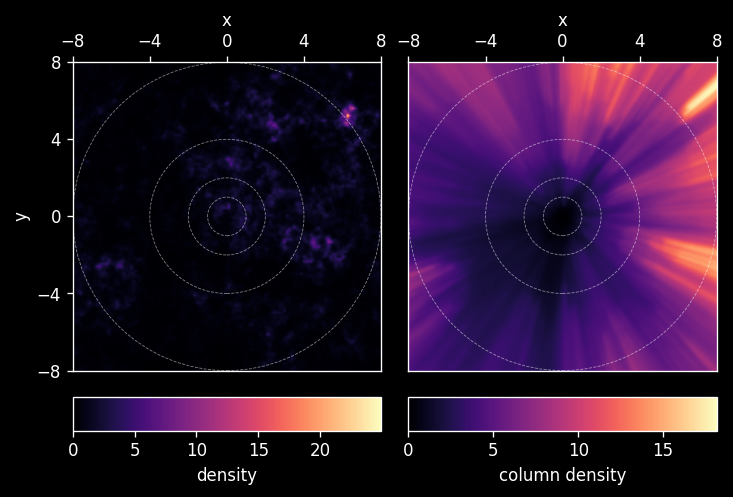

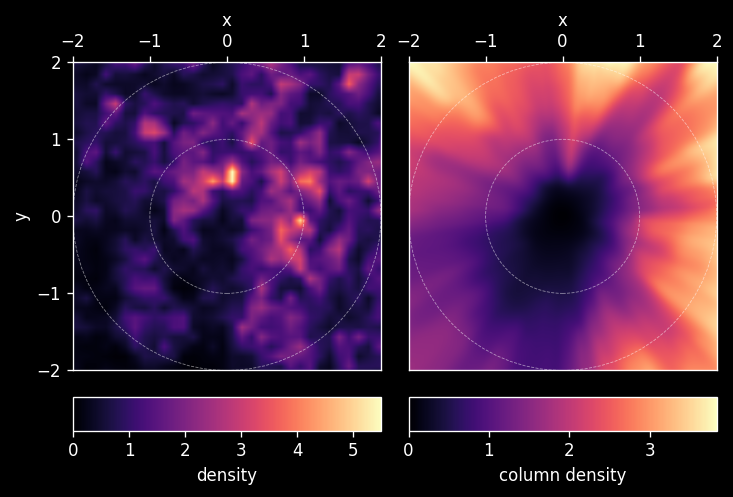

In [55]:
# Two versions of the figure at different zooms
for plot_lim in [r_max, min([4, r_max/4])]:
    img_shape = [1024, 1024]#[2*n for n in n_modes[:2]]
    xyz_grid = np.array(np.meshgrid(
        np.linspace(-plot_lim, plot_lim, img_shape[0]),
        np.linspace(-plot_lim, plot_lim, img_shape[1]),
        np.zeros(1),
        indexing='ij'
    )).reshape(3, -1).T  # shape (N, 3)

    fig,ax_arr = plt.subplots(
        2, 2,
        figsize=(6,4),
        height_ratios=[1,0.1],
        constrained_layout=True
    )

    # Left panel: density map
    ax = ax_arr[0,0]
    im = ax.imshow(
        rho_dust_interp(xyz_grid).reshape(img_shape),
        origin='lower',
        aspect='equal',
        extent=(-plot_lim, plot_lim, -plot_lim, plot_lim),
        cmap='magma',
        vmin=0.
    )
    fig.colorbar(
        im,
        cax=ax_arr[1,0],
        label='density',
        orientation='horizontal'
    )
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    # Put x-axis ticks and label on top
    ax.xaxis.set_label_position('top')
    ax.xaxis.set_ticks_position('top')
    # Tick locators
    ax.xaxis.set_major_locator(MaxNLocator(4))
    ax.yaxis.set_major_locator(MaxNLocator(4))

    # Right panel: integrated dust map
    ax = ax_arr[0,1]
    im = ax.imshow(
        integrated_dust_interp(xyz_grid).reshape(img_shape),
        origin='lower',
        aspect='equal',
        extent=(-plot_lim, plot_lim, -plot_lim, plot_lim),
        cmap='magma',
        vmin=0.
    )
    fig.colorbar(
        im,
        cax=ax_arr[1,1],
        label='column density',
        orientation='horizontal'
    )
    ax.set_xlabel('x')
    # Put x-axis ticks and label on top
    ax.xaxis.set_label_position('top')
    ax.xaxis.set_ticks_position('top')
    # Tick locators
    ax.xaxis.set_major_locator(MaxNLocator(4))
    ax.set_yticks([]) # Get rid of y-axis ticks

    # Plot circles of constant radius
    for ax in ax_arr[0,:]:
        for r in [1,2,4,8]:
            circle = plt.Circle((0,0), r, color='white', fill=False, ls='--', lw=0.5, alpha=0.5)
            ax.add_artist(circle)
    
    plt.show()

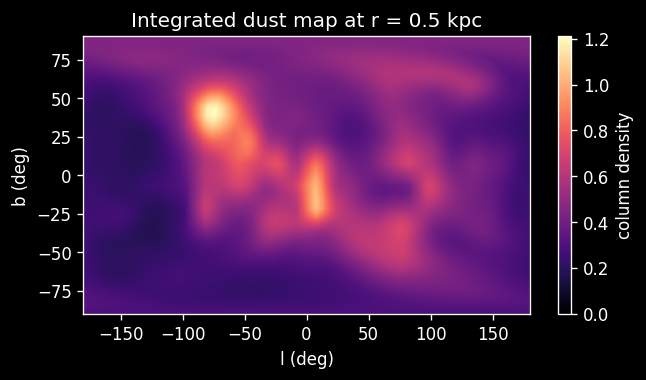

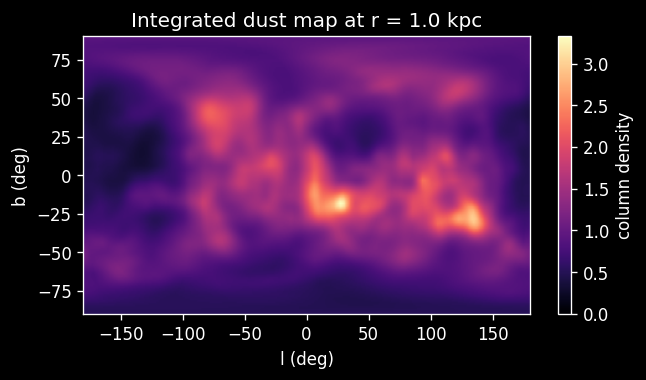

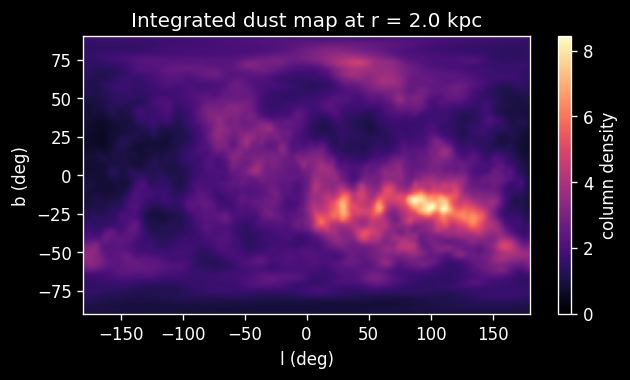

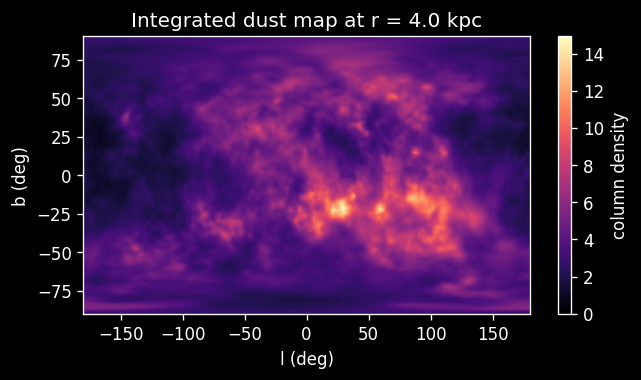

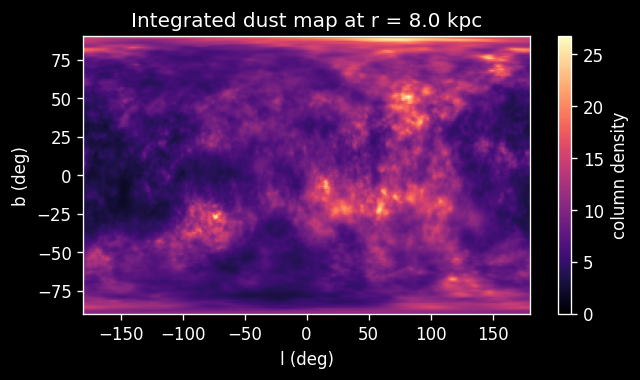

In [56]:
# Plot Cartesian sky projections of distance slices of integrated dust map

r_vals = [0.5, 1.0, 2.0, 4.0, 8.0]  # kpc

l_vals = np.radians(np.linspace(-180, 180.01, 360))
b_vals = np.radians(np.linspace(-90, 90.01, 180))
l,b = np.meshgrid(l_vals, b_vals, indexing='ij')

# Points on unit sphere
xyz_unit = np.stack([
    np.cos(b) * np.cos(l),
    np.cos(b) * np.sin(l),
    np.sin(b)
], axis=-1)  # shape (N_l, N_b, 3)
xyz_unit.shape = (-1, 3)  # shape (N_l*N_b, 3)

for r in r_vals:
    img = integrated_dust_interp(xyz_unit * r)
    img.shape = l.shape

    plt.figure(figsize=(6,3))
    plt.imshow(
        img.T,
        origin='lower',
        extent=[-180,180,-90,90],
        cmap='magma',
        aspect='auto',
        vmin=0
    )
    plt.colorbar(label='column density')
    plt.title(f'Integrated dust map at r = {r:.1f} kpc')
    plt.xlabel('l (deg)')
    plt.ylabel('b (deg)')
    plt.show()

## Draw stars from Plummer sphere DF

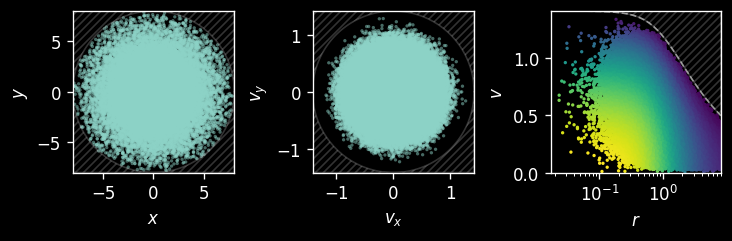

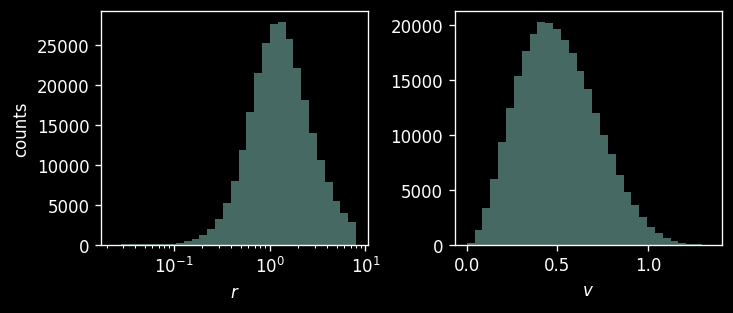

In [11]:
n_stars = 1024*256 # Number of stars to sample

x_samp,v_samp = dist_fn.sample_df(n_stars, r_max=r_max, rng=rng)

fig,ax_arr = plt.subplots(1, 3, figsize=(6,1.9), constrained_layout=True)

# (x,y) projection
ax = ax_arr[0]
ax.scatter(
    x_samp[:,0], x_samp[:,1],
    s=4, alpha=0.5, edgecolors='none'
)
ax.set_xlim(-r_max,r_max)
ax.set_ylim(-r_max,r_max)
ax.set_aspect('equal')
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')

# Hatch region beyond r_max in the (x,y) plane, using
# two fill_between calls to get a circular hatched region
x = np.linspace(-r_max, r_max, 256)
y_pos = np.sqrt(r_max**2 - x**2)
ax.fill_between(
    x, y_pos, r_max,
    facecolor='none', edgecolor='w',
    hatch='/////', alpha=0.2
)
ax.fill_between(
    x, -r_max, -y_pos,
    facecolor='none', edgecolor='w',
    hatch='/////', alpha=0.2
)

# (vx,vy) projection
ax = ax_arr[1]
ax.scatter(
    v_samp[:,0], v_samp[:,1],
    s=4, alpha=0.5, edgecolors='none'
)
v_max = np.sqrt(2)
ax.set_xlim(-v_max,v_max)
ax.set_ylim(-v_max,v_max)
ax.set_aspect('equal')
ax.set_xlabel('$v_x$')
ax.set_ylabel('$v_y$')

# Hatch region above escape velocity (v_esc = sqrt(2))
# This will be everything beyond a radius of sqrt(2)
# in the (vx,vy) plane
vx = np.linspace(-v_max, v_max, 256)
vy_pos = np.sqrt(v_max**2 - vx**2)
ax.fill_between(
    vx, vy_pos, v_max,
    facecolor='none', edgecolor='w',
    hatch='/////', alpha=0.2
)
ax.fill_between(
    vx, -v_max, -vy_pos,
    facecolor='none', edgecolor='w',
    hatch='/////', alpha=0.2
)

# (r,v) projection
ax = ax_arr[2]
r = np.linalg.norm(x_samp, axis=1)
v = np.linalg.norm(v_samp, axis=1)
ax.scatter(
    r, v,
    c=-dist_fn.energy(x_samp, v_samp),  # color by energy
    # norm=LogNorm(),
    s=4, alpha=1, edgecolors='none'
)
ax.set_xscale('log')
ax.set_xlim(right=r_max)
# ax.set_ylim(0,v_max)
# ax.set_aspect('equal')
ax.set_xlabel('$r$')
ax.set_ylabel('$v$')

# Plot escape velocity curve
rlim = ax.get_xlim()
r_plot = np.logspace(np.log10(rlim[0]), np.log10(rlim[1]), 256)
v_esc = np.sqrt(-2*dist_fn.phi(r_plot))
ax.plot(r_plot, v_esc, 'w--', lw=1, alpha=0.5)
# Fill region above escape velocity with hatching
ax.fill_between(
    r_plot, v_esc, v_max,
    facecolor='none', edgecolor='w',
    hatch='/////', alpha=0.2
)
ax.set_xlim(rlim)
ax.set_ylim(0,v_max)

plt.show()

# Histograms of r and v
fig,ax_arr = plt.subplots(1, 2, figsize=(6,2.5), constrained_layout=True)

ax = ax_arr[0]
r = np.linalg.norm(x_samp, axis=1)
r_grid = np.logspace(np.log10(np.min(r)), np.log10(r_max), 32)
ax.hist(r, bins=r_grid, density=False, histtype='stepfilled', alpha=0.5)
# ax.plot(r_grid, dist_fn.pdf_r(r_grid), 'k-', lw=1)
ax.set_xscale('log')
ax.set_xlabel('$r$')
ax.set_ylabel('counts')

ax = ax_arr[1]
v = np.linalg.norm(v_samp, axis=1)
v_grid = np.linspace(0, np.max(v), 32)
ax.hist(v, bins=v_grid, density=False, histtype='stepfilled', alpha=0.5)
ax.set_xlabel('$v$')
# ax.set_ylabel('counts')

plt.show()

# Apply selection function to mock stars

We draw the absolute magnitude of each star from a Gaussian distribution, and then look up the extinction (based on the integrated dust density at the star's position), allowing us to calculate the star's apparent magnitude. We apply a sharp cut at a specified limiting magnitude.

In [ ]:
M_mean, M_sigma = 5.0, 2.0 # Mean and std. dev. of absolute magnitude distribution
m_max = 18.0 # Limiting apparent magnitude of the survey

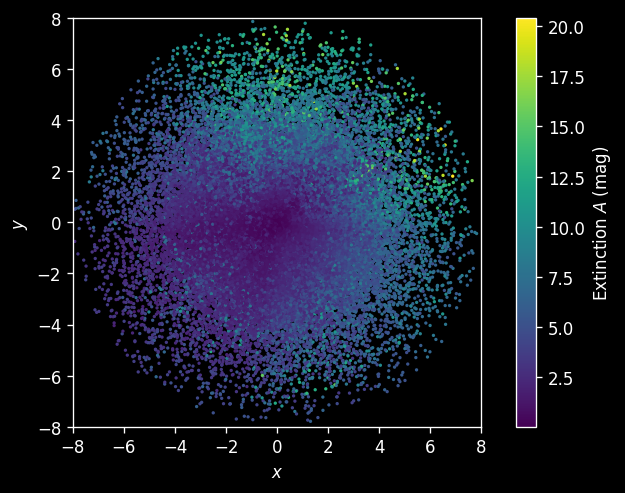

In [ ]:
# Draw absolute magnitude for each star
M = rng.normal(M_mean, M_sigma, size=len(x_samp))

# Integrate dust density along each line of sight
A = integrated_dust_interp(x_samp)

# Calculate distance modulus and apparent magnitude
dm = 5 * np.log10(r/0.01) # distance modulus (assuming r is in kpc)
m = M + dm + A # apparent magnitude

# Plot (x,y) projection of all stars with extinction
fig,ax = plt.subplots(1, 1, figsize=(6,4), constrained_layout=True)
im = ax.scatter(
    x_samp[:,0], x_samp[:,1],
    c=A[:],
    s=4, edgecolors='none'
)
ax.set_xlim(-r_max,r_max)
ax.set_ylim(-r_max,r_max)
ax.set_aspect('equal')
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Extinction $A$ (mag)')
plt.show()

Number of stars with m < 18.0: 159038 (60.7%)


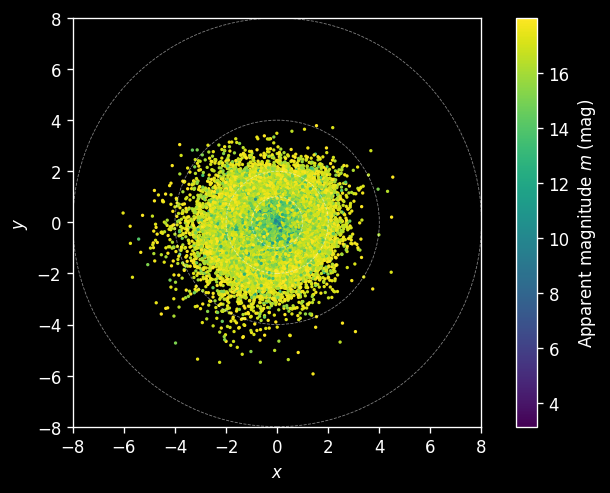

In [ ]:
# Cut to m < m_max
idx = (m < m_max)
print(f'Number of stars with m < {m_max}: {np.sum(idx)} ({np.mean(idx):.1%})')

# Plot (x,y) projection of stars that make the apparent magnitude cut
fig,ax = plt.subplots(1, 1, figsize=(6,4), constrained_layout=True)
im = ax.scatter(
    x_samp[idx,0], x_samp[idx,1],
    c=m[idx],
    s=4, edgecolors='none'
)
ax.set_xlim(-r_max,r_max)
ax.set_ylim(-r_max,r_max)
ax.set_aspect('equal')
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Apparent magnitude $m$ (mag)')

# Draw circles of constant radius
for r in [1,2,4,8]:
    circle = plt.Circle((0,0), r, color='white', fill=False, ls='--', lw=0.5, alpha=0.5)
    ax.add_artist(circle)

plt.show()

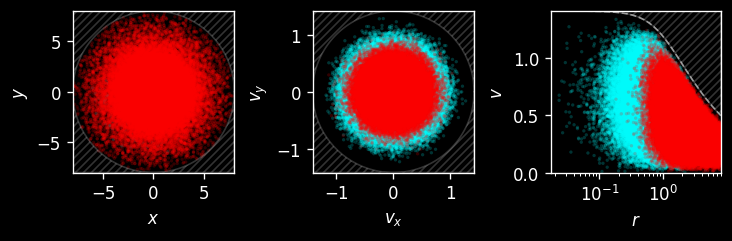

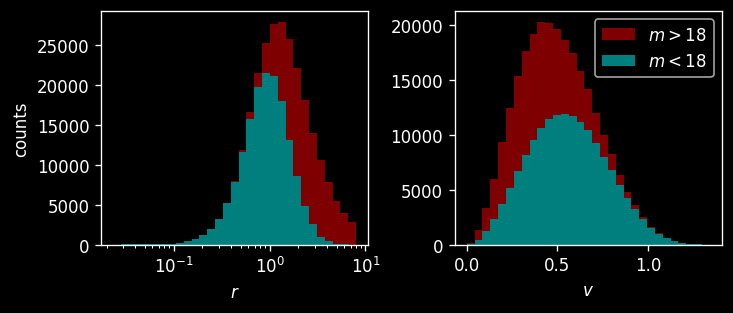

In [14]:
# Plot phase-space projections of stars that do and do not make the apparent magnitude cut

x_sel = x_samp[idx]
v_sel = v_samp[idx]
x_nosel = x_samp[~idx]
v_nosel = v_samp[~idx]

fig,ax_arr = plt.subplots(1, 3, figsize=(6,1.9), constrained_layout=True)

# (x,y) projection
ax = ax_arr[0]
ax.scatter(
    x_sel[:,0], x_sel[:,1],
    s=4, alpha=0.2, edgecolors='none',
    facecolors='cyan'
)
ax.scatter(
    x_nosel[:,0], x_nosel[:,1],
    s=4, alpha=0.2, edgecolors='none',
    facecolors='red'
)
ax.set_xlim(-r_max,r_max)
ax.set_ylim(-r_max,r_max)
ax.set_aspect('equal')
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')

# Hatch region beyond r_max in the (x,y) plane, using
# two fill_between calls to get a circular hatched region
x = np.linspace(-r_max, r_max, 256)
y_pos = np.sqrt(r_max**2 - x**2)
ax.fill_between(
    x, y_pos, r_max,
    facecolor='none', edgecolor='w',
    hatch='/////', alpha=0.2
)
ax.fill_between(
    x, -r_max, -y_pos,
    facecolor='none', edgecolor='w',
    hatch='/////', alpha=0.2
)

# (vx,vy) projection
ax = ax_arr[1]
ax.scatter(
    v_sel[:,0], v_sel[:,1],
    s=4, alpha=0.2, edgecolors='none',
    facecolors='cyan'
)
ax.scatter(
    v_nosel[:,0], v_nosel[:,1],
    s=4, alpha=0.2, edgecolors='none',
    facecolors='red'
)
v_max = np.sqrt(2)
ax.set_xlim(-v_max,v_max)
ax.set_ylim(-v_max,v_max)
ax.set_aspect('equal')
ax.set_xlabel('$v_x$')
ax.set_ylabel('$v_y$')

# Hatch region above escape velocity (v_esc = sqrt(2))
# This will be everything beyond a radius of sqrt(2)
# in the (vx,vy) plane
vx = np.linspace(-v_max, v_max, 256)
vy_pos = np.sqrt(v_max**2 - vx**2)
ax.fill_between(
    vx, vy_pos, v_max,
    facecolor='none', edgecolor='w',
    hatch='/////', alpha=0.2
)
ax.fill_between(
    vx, -v_max, -vy_pos,
    facecolor='none', edgecolor='w',
    hatch='/////', alpha=0.2
)

# (r,v) projection
ax = ax_arr[2]
r = np.linalg.norm(x_samp, axis=1)
v = np.linalg.norm(v_samp, axis=1)
r_sel = r[idx]
v_sel = v[idx]
r_nosel = r[~idx]
v_nosel = v[~idx]
ax.scatter(
    r_sel, v_sel,
    s=4, alpha=0.2, edgecolors='none',
    facecolors='cyan'
)
ax.scatter(
    r_nosel, v_nosel,
    s=4, alpha=0.2, edgecolors='none',
    facecolors='red'
)
ax.set_xscale('log')
ax.set_xlim(right=r_max)
# ax.set_ylim(0,v_max)
# ax.set_aspect('equal')
ax.set_xlabel('$r$')
ax.set_ylabel('$v$')

# Plot escape velocity curve
rlim = ax.get_xlim()
r_plot = np.logspace(np.log10(rlim[0]), np.log10(rlim[1]), 256)
v_esc = np.sqrt(-2*dist_fn.phi(r_plot))
ax.plot(r_plot, v_esc, 'w--', lw=1, alpha=0.5)
# Fill region above escape velocity with hatching
ax.fill_between(
    r_plot, v_esc, v_max,
    facecolor='none', edgecolor='w',
    hatch='/////', alpha=0.2
)
ax.set_xlim(rlim)
ax.set_ylim(0,v_max)

plt.show()

# Histograms of r and v. Stack selected and not selected.
fig,ax_arr = plt.subplots(1, 2, figsize=(6,2.5), constrained_layout=True)

ax = ax_arr[0]
r = np.linalg.norm(x_samp, axis=1)
r_grid = np.logspace(np.log10(np.min(r)), np.log10(r_max), 32)
ax.hist(
    [r_sel,r_nosel],
    stacked=True,
    bins=r_grid,
    density=False,
    histtype='stepfilled',
    color=['cyan','red'],
    alpha=0.5
)
# ax.plot(r_grid, dist_fn.pdf_r(r_grid), 'k-', lw=1)
ax.set_xscale('log')
ax.set_xlabel('$r$')
ax.set_ylabel('counts')

ax = ax_arr[1]
v = np.linalg.norm(v_samp, axis=1)
v_grid = np.linspace(0, np.max(v), 32)
ax.hist(
    [v_sel,v_nosel],
    stacked=True,
    bins=v_grid,
    density=False,
    histtype='stepfilled',
    color=['cyan','red'],
    alpha=0.5,
    label=[r'$m < 18$',r'$m > 18$']
)
ax.set_xlabel('$v$')
ax.legend()

plt.show()

## Observation probability

In order to recover the true distribution function, Deep Potential needs to know the selection function of each star. We calculate the observation probability of each star, conditional on its distance and extinction (marginalizing over absolute magnitude):
$$
  p\left(S=1 \mid \mu, A, M\right) =
    \begin{cases}
      1 \ , & M + \mu + A < m_{\mathrm{lim}} \\
      0 \ , & \mathrm{otherwise}
    \end{cases}
    \, .
$$
Recall that in this mock dataset,
$$
  p\left(M\right) = \mathcal{N}\left(M \mid M_0, \sigma_M\right)
  \, .
$$
Marginalizing over absolute magnitude $M$,
$$
  \begin{align}
    p(S=1 \mid \mu, A)
      &= \int p\left(S=1 \mid \mu, A, M\right) p\left(M\right) \mathrm{d}M \\
      &= \int_{-\infty}^{m_{\mathrm{lim}}-\mu-A} \hspace{-3.5em}
           \mathcal{N}\left(M \mid M_0, \sigma_M\right) \mathrm{d}M \\
      &= \frac{1}{2} \left[
           1 + \mathrm{erf}\left(
             \frac{
               m_{\mathrm{lim}} - M_0 - \mu - A
             }{
               \sqrt{2} \, \sigma_M
             }
           \right)
         \right]
      \, .
  \end{align}
$$

In [15]:
# Calculate observation probability of each star, given its position and extinction
p_obs = 0.5 * (1 + scipy.special.erf((m_max - M_mean - dm - A) / (np.sqrt(2)*M_sigma)))

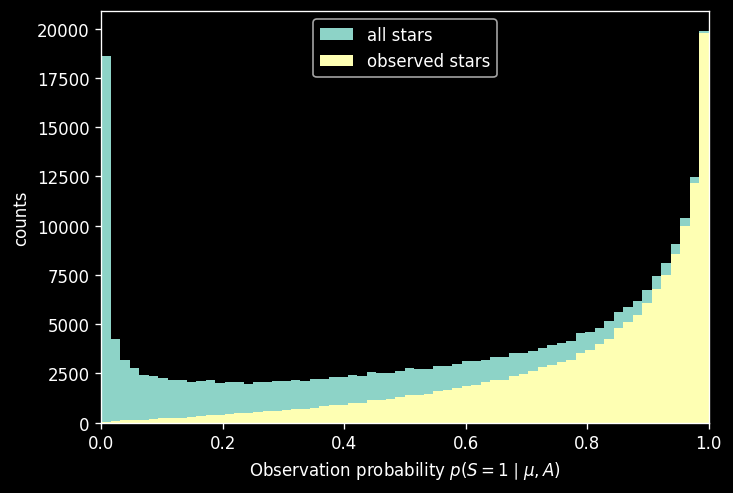

In [16]:
fig,ax = plt.subplots(1, 1, figsize=(6,4), constrained_layout=True)
ax.hist(p_obs, bins=np.linspace(0,1,65), histtype='stepfilled', label='all stars')
ax.hist(p_obs[idx], bins=np.linspace(0,1,65), histtype='stepfilled', label='observed stars')
ax.set_xlim(0,1)
ax.set_xlabel(r'Observation probability $p\left(S=1 \mid \mu, A\right)$')
ax.set_ylabel('counts')
ax.legend()
plt.show()

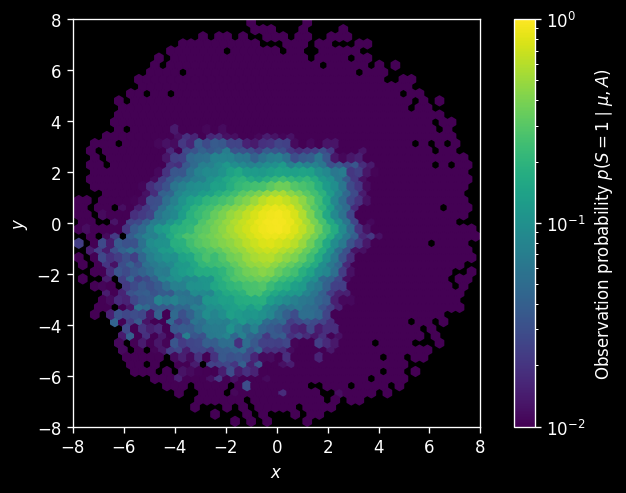

In [57]:
# (x,y) projection of observation probability. Use hexbin.
fig,ax = plt.subplots(1, 1, figsize=(6,4), constrained_layout=True)
im = ax.hexbin(
    x_samp[:,0], x_samp[:,1],
    C=p_obs,
    gridsize=50,
    reduce_C_function=np.mean,
    # vmin=0, vmax=1,
    cmap='viridis',
    norm=LogNorm(vmin=1e-2, vmax=1)
)
ax.set_xlim(-r_max,r_max)
ax.set_ylim(-r_max,r_max)
ax.set_aspect('equal')
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
cbar = plt.colorbar(im, ax=ax)
cbar.set_label(r'Observation probability $p\left(S=1 \mid \mu, A\right)$')
plt.show()

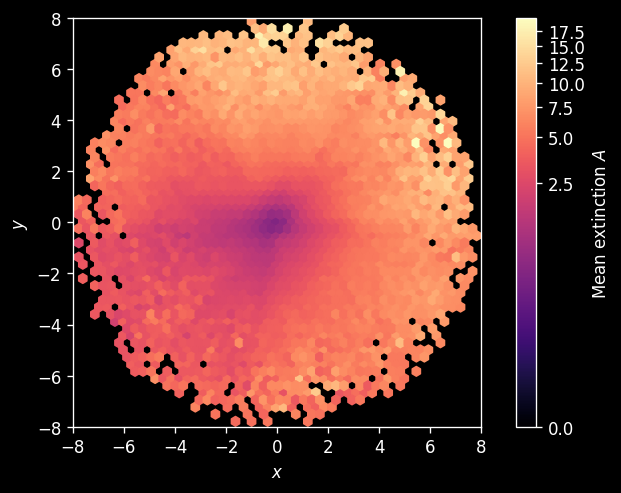

In [58]:
# (x,y) projection of mean extinction. Use hexbin and power-law color scale.
fig,ax = plt.subplots(1, 1, figsize=(6,4), constrained_layout=True)
im = ax.hexbin(
    x_samp[:,0], x_samp[:,1],
    C=A,
    gridsize=50,
    reduce_C_function=np.mean,
    cmap='magma',
    norm=PowerNorm(gamma=0.25, vmin=0)
)
ax.set_xlim(-r_max,r_max)
ax.set_ylim(-r_max,r_max)
ax.set_aspect('equal')
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
cbar = plt.colorbar(im, ax=ax)
cbar.set_label(r'Mean extinction $A$')
plt.show()

In [59]:
import h5py

# Save a version of the dataset with all the stars
fn = 'plummer_sphere_allstars.h5'

# Combine x and v into phase-space coordinates eta
eta = np.concatenate([x_samp, v_samp], axis=1).astype('f4')  # shape (n, 6)
weights = np.ones(len(eta)).astype('f4')  # Unit weight for each star

# HDF5 dataset options
kw = dict(compression='gzip', compression_opts=5, chunks=True)

with h5py.File(fn, 'w') as f:
    f.create_dataset('eta', data=eta, **kw)
    f.create_dataset('weights', data=weights, **kw)
    # Extra information about stars
    f.create_dataset('m', data=m.astype('f4'), **kw)
    f.create_dataset('A', data=A.astype('f4'), **kw)
    f.create_dataset('p_obs', data=p_obs.astype('f4'), **kw)
    f.create_dataset('S', data=idx.astype('u1'), **kw)

! du -sh {fn}
! h5ls -v {fn}

8.3M	plummer_sphere_allstars.h5
Opened "plummer_sphere_allstars.h5" with sec2 driver.
A                        Dataset {262144/262144}
    Location:  1:6766578
    Links:     1
    Chunks:    {4096} 16384 bytes
    Storage:   1048576 logical bytes, 944695 allocated bytes, 111.00% utilization
    Filter-0:  deflate-1 OPT {5}
    Type:      native float
S                        Dataset {262144/262144}
    Location:  1:8655266
    Links:     1
    Chunks:    {8192} 8192 bytes
    Storage:   262144 logical bytes, 45002 allocated bytes, 582.52% utilization
    Filter-0:  deflate-1 OPT {5}
    Type:      native unsigned char
eta                      Dataset {262144/262144, 6/6}
    Location:  1:800
    Links:     1
    Chunks:    {8192, 1} 32768 bytes
    Storage:   6291456 logical bytes, 5854009 allocated bytes, 107.47% utilization
    Filter-0:  deflate-1 OPT {5}
    Type:      native float
m                        Dataset {262144/262144}
    Location:  1:5873609
    Links:     1
    Chunk

In [60]:
# Save a version of the dataset with only the stars that make the apparent magnitude cut
fn = 'plummer_sphere_obsstars.h5'

with h5py.File(fn, 'w') as f:
    f.create_dataset('eta', data=eta[idx], **kw)

    # Unit weights, even though selection is non-uniform
    f.create_dataset('weights', data=weights[idx], **kw)

    # Extra information about stars
    f.create_dataset('m', data=m[idx].astype('f4'), **kw)
    f.create_dataset('A', data=A[idx].astype('f4'), **kw)

    # p(S=1 | mu, A) for each star that was observed. Can be used
    # to calculate weights.
    f.create_dataset('p_obs', data=p_obs[idx].astype('f4'), **kw)

! du -sh {fn}
! h5ls -v {fn}


5.0M	plummer_sphere_obsstars.h5
Opened "plummer_sphere_obsstars.h5" with sec2 driver.
A                        Dataset {159038/159038}
    Location:  1:4110992
    Links:     1
    Chunks:    {4970} 19880 bytes
    Storage:   636152 logical bytes, 570552 allocated bytes, 111.50% utilization
    Filter-0:  deflate-1 OPT {5}
    Type:      native float
eta                      Dataset {159038/159038, 6/6}
    Location:  1:800
    Links:     1
    Chunks:    {4970, 1} 19880 bytes
    Storage:   3816912 logical bytes, 3553591 allocated bytes, 107.41% utilization
    Filter-0:  deflate-1 OPT {5}
    Type:      native float
m                        Dataset {159038/159038}
    Location:  1:3572487
    Links:     1
    Chunks:    {4970} 19880 bytes
    Storage:   636152 logical bytes, 536137 allocated bytes, 118.65% utilization
    Filter-0:  deflate-1 OPT {5}
    Type:      native float
p_obs                    Dataset {159038/159038}
    Location:  1:4683912
    Links:     1
    Chunks:    {

## Optimal loss calculation

Calculate the optimal loss (negative log likelihood) of the unit Plummer sphere distribution function. We will perform a Monte Carlo estimate of the integral
$$
  L \equiv \int
    \left[ -\ln f\left(\vec{\eta}\right) \right]
    f\left(\vec{\eta}\right) \mathrm{d}^6\vec{\eta}
  \, .
$$
We estimate this integral by drawing samples from the distribution function $f\left(\vec{\eta}\right)$, and then averaging $-\ln f\left(\vec{\eta}\right)$ over them.

Because we have only drawn samples out to a maximum radius of $r_{\mathrm{max}}$, we have to make a small correction to the normalizations of the ideal Plummer sphere distribution function. The total mass enclosed at a radius of $r_{\mathrm{max}}$ is given by
$$
  M_{\mathrm{encl}} = \frac{r_{\mathrm{max}}^3}{\left(1+r_{\mathrm{max}}^2\right)^{3/2}} \, .
$$
The distribution function is then given by $f_{\mathrm{corr}}\left(\vec{\eta}\right) = f\left(\vec{\eta}\right) / M_{\mathrm{encl}}$, where $f$ is the distribution function without the correction. The loss is then given by $L = \ln M_{\mathrm{encl}} - \langle \ln f\left(\vec{\eta}\right) \rangle$.

In order to calculate the optimal loss after application of the selection function, we have to modify the above calculation. With the selection function $S$ (which is in practice a function of position only, but which could theoretically depend on velocity as well), the distribution function becomes
$$
  \tilde{f}\left(\eta\right) = \frac{1}{\tilde{\mathcal{Z}}} f\left(\eta\right)S\left(\eta\right) \, ,
$$
where $\tilde{\mathcal{Z}}$ is a normalization factor based on the integral of the modified distribution function:
$$
  \tilde{\mathcal{Z}}
    = \int f\left(\eta\right)S\left(\eta\right) \mathcal{d}^6\vec{\eta}
    = \langle S\left(\eta\right) \rangle \, ,
$$
where the average is taken over samples drawn from the ideal distribution function. The optimal loss is then given by
$$
\begin{align}
  \tilde{L}
  &= \int
       \left[ -\ln \tilde{f}\left(\vec{\eta}\right) \right]
       \tilde{f}\left(\vec{\eta}\right) \mathrm{d}^6\vec{\eta}
     \\
  &= \int
       \left[ \ln\tilde{\mathcal{Z}} - \ln f\left(\vec{\eta}\right) - \ln S\left(\vec{\eta}\right) \right]
       \tfrac{1}{\tilde{\mathcal{Z}}} S\left(\vec{\eta}\right) f\left(\vec{\eta}\right) \mathrm{d}^6\vec{\eta}
     \\
  &= \tfrac{1}{\tilde{\mathcal{Z}}}
     \langle
       \left[ \ln\tilde{\mathcal{Z}} - \ln f\left(\vec{\eta}\right) - \ln S\left(\vec{\eta}\right) \right]
       S\left(\vec{\eta}\right)
     \rangle
     \, .
\end{align}
$$

In [7]:
from tqdm.auto import tqdm

In [8]:
mass_encl = r_max**3 / (1 + r_max**2)**1.5
print(f'Mass enclosed within r_max = {r_max}: {mass_encl:.5f}')

Mass enclosed within r_max = 8.0: 0.97701


In [8]:
def lnp_obs_of_xyz(xyz):
    r = np.linalg.norm(xyz, axis=1)
    dm = 5 * np.log10(r/0.01) # Assumes r has units of kpc
    A = integrated_dust_interp(xyz)
    return scipy.special.log_ndtr((m_max - M_mean - dm - A) / M_sigma)
    # return 0.5 * (1 + scipy.special.erf((m_max - M_mean - dm - A) / (np.sqrt(2)*M_sigma)))

In [ ]:
rng_loss = np.random.default_rng(1)

n_samp_per_batch = 1024*16
n_batches = 1024

loss_opt = []
loss_opt_selfn = []

for i in tqdm(range(n_batches)):
    xx,vv = dist_fn.sample_df(n_samp_per_batch, r_max=r_max, rng=rng_loss)
    loss_opt.append(
        np.log(mass_encl)                     # Volume truncation term
        - np.mean(np.log(dist_fn.df(xx, vv))) # Ideal distribution function term
    )
    # Selection function correction
    lnp = lnp_obs_of_xyz(xx)
    lnZ = scipy.special.logsumexp(lnp_obs_of_xyz(xx)) - np.log(len(xx))
    loss_opt_selfn.append(np.mean(
        (lnZ - np.log(dist_fn.df(xx, vv)) - lnp) * np.exp(lnp)
    ) / np.exp(lnZ))

loss_opt_mean = np.mean(loss_opt)
loss_opt_std = np.std(loss_opt) / np.sqrt(n_batches)

print(f'Optimal loss (negative log likelihood): {loss_opt_mean:.5f} +- {loss_opt_std:.5f}')

loss_opt_selfn_mean = np.mean(loss_opt_selfn)
loss_opt_selfn_std = np.std(loss_opt_selfn) / np.sqrt(n_batches)

print(f'Optimal loss (negative log likelihood) with selection function: {loss_opt_selfn_mean:.5f} +- {loss_opt_selfn_std:.5f}')

# Plot results

## Load models and precomputed gradients

In [22]:
# Load trained potential model

import json
import sys
sys.path.append('../')  # Add parent directory to Python path
import fit_all
import utils
from pathlib import Path

run_dir = Path('../../runs/plummer_noselfn_2_snake')

phi_model = fit_all.load_potential(run_dir / 'models/Phi_12_n8')

Initializing the neural network with coordinate scale [1.210059642791748, 1.2206275463104248, 1.2185652256011963]
Loading model from ../../runs/plummer_noselfn_2_snake/models/Phi_12_n8/potential-0_model.eqx
Loading checkpoint index 0
Model loaded!


In [5]:
flow_model, flow_loss_history = fit_all.load_flow(
    run_dir / 'models/df/flow_12_0',
    load_history=True
)

Loading model from ../../runs/plummer_noselfn_2_snake/models/df/flow_12_0/flow-0_model.eqx
Loading checkpoint index 0
Model loaded!
Loading loss history from ../../runs/plummer_noselfn_2_snake/models/df/flow_12_0/flow-0_loss.json


/data/beegfs/astro-storage/groups/green/kalda/projects/deep-potential/scripts/plummer/../flow_vector_fields.py:652: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  self.dynamics_net = SHPosTimeResMLP(


In [7]:
# Load precomputed DF gradients
import h5py
fn = run_dir / 'data/df_gradients_12_n8.h5'

with h5py.File(fn, 'r') as f:
    print(f.keys())
    flow_grads = {k: f[k][:] for k in f.keys()}

print(f'Loaded {len(flow_grads["f"])} precomputed DF gradients.')


<KeysViewHDF5 ['df_deta', 'eta', 'f']>
Loaded 262144 precomputed DF gradients.


## Potential plots

In [8]:
%matplotlib inline

In [9]:
from utils import get_model_values

# Evaluate model on grid of points
r_grid = np.logspace(-2, np.log10(r_max), 64)

# Pick points on sphere
from plummer_sphere import draw_from_sphere
n_points_per_radius = 512
xyz = draw_from_sphere(n_points_per_radius*len(r_grid), rng=rng)
s = (len(r_grid), n_points_per_radius)
xyz.shape = s + (3,)
xyz *= r_grid[:,None,None]  # Scale to each radius
xyz.shape = (-1, 3)
# xyz = jnp.array(xyz)

phi_eval,acc_eval,rho_eval = get_model_values(
    phi_model, xyz,
    convert_rho_to_msunpc3=False,
    disable_tqdm=True
)

# Reshape output to (n_radii, n_points_per_radius)
phi_eval.shape = s
acc_eval.shape = s + (3,)
rho_eval.shape = s

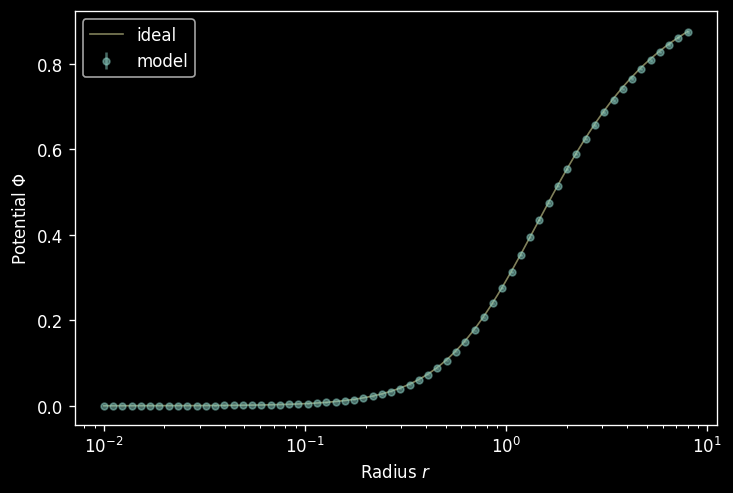

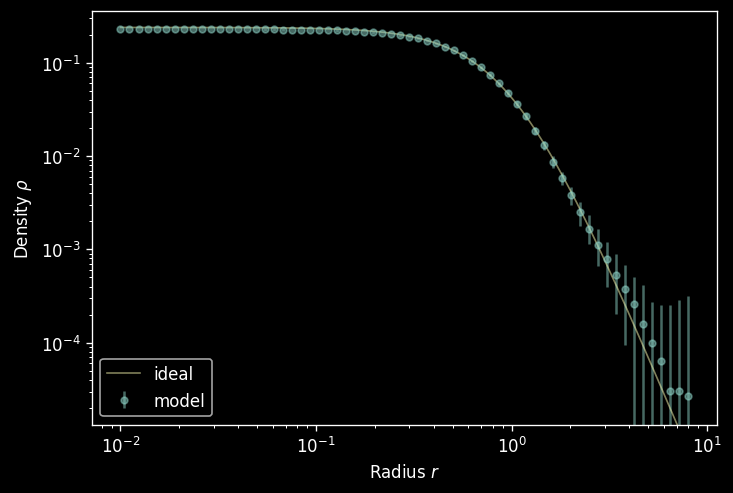

In [10]:
# Plot potential and density profiles as a function of radius

### Potential
fig,ax = plt.subplots(1, 1, figsize=(6,4), constrained_layout=True)
# Trained potential
phi_low,phi_med,phi_up = np.percentile(phi_eval, [16,50,84], axis=1)
yerr = np.stack([phi_med - phi_low, phi_up - phi_med], axis=0)
phi_med -= phi_med[0]  # Set phi(r_min) = 0
ax.errorbar(
    r_grid,
    phi_med,
    yerr=yerr,
    linestyle='none',
    marker='o',
    markersize=4,
    alpha=0.5,
    label='model'
)
# Ideal potential
r_plot = np.logspace(np.log10(r_grid[0]), np.log10(r_grid[-1]), 256)
phi_ideal = dist_fn.phi(r_plot) - dist_fn.phi(r_grid[0])
ax.plot(r_plot, phi_ideal, alpha=0.5, lw=1, label='ideal')
# Formatting, labels, etc.
ax.set_xscale('log')
ax.set_xlabel('Radius $r$')
ax.set_ylabel(r'Potential $\Phi$')
ax.legend(loc='upper left')

### Density
fig,ax = plt.subplots(1, 1, figsize=(6,4), constrained_layout=True)
# Trained density
rho_low,rho_med,rho_up = np.percentile(rho_eval, [16,50,84], axis=1)
yerr = np.stack([rho_med - rho_low, rho_up - rho_med], axis=0)
ax.errorbar(
    r_grid,
    rho_med,
    yerr=yerr,
    linestyle='none',
    marker='o',
    markersize=4,
    alpha=0.5,
    label='model'
)
# Ideal density
rho_ideal = dist_fn.rho(r_plot)
ax.plot(r_plot, rho_ideal, alpha=0.5, lw=1, label='ideal')
# Formatting, labels, etc.
ax.set_ylim(
    max(0.5*np.min(rho_med), 1e-5*np.min(rho_ideal)),
    1.5*max(np.max(rho_med+yerr[1]), np.max(rho_ideal))
)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Radius $r$')
ax.set_ylabel(r'Density $\rho$')
ax.legend(loc='lower left')

plt.show()

## DF gradients

Because the Plummer-sphere DF has a known analytic form, we can compare the gradients of our trained normalizing flow to the ideal (true) gradients.

In [11]:
# Compare gradients with the ideal Plummer sphere DF gradients

# Next, calculate the ideal gradients using JAX
import jax
import jax.numpy as jnp
# Unit Plummer sphere potential
pot_ideal = lambda x: -1 / jnp.sqrt(1 + jnp.sum(x**2, axis=-1))
# Kinetic energy term
kinetic_energy = lambda v: 0.5 * jnp.sum(v**2, axis=-1)
# Energy function of (x,v)
energy_ideal = lambda x,v: kinetic_energy(v) + pot_ideal(x)
# Distribution function of (x,v). Make sure to use jnp.where to avoid NaNs.
df_ideal = lambda x,v: jnp.where(
    energy_ideal(x,v) < 0,
    (-energy_ideal(x,v))**(7/2) * (24*jnp.sqrt(2)) / (7*jnp.pi**3),
    0.0
)
# Make function of eta = (x,v)
df_ideal_eta = lambda eta: df_ideal(eta[:3], eta[3:])
# Gradient of DF with respect to eta.
grad_df_ideal = jax.jit(jax.grad(
    lambda eta: df_ideal_eta(eta).sum(),
    argnums=(0,)
))

In [12]:
mass_encl = r_max**3 / (1 + r_max**2)**(3/2)

In [13]:
# Calculate gradients of DF at the sampled points.
# Need to concatenate x and v into single argument before passing in.
df_grad_ideal = np.stack(
    jax.vmap(grad_df_ideal)(jnp.array(flow_grads['eta'])),
    axis=-1
)
df_grad_ideal = df_grad_ideal.reshape(-1, 6)
# Shape (n_samp, 6), where the last axis is (d/dx, d/dv)

# Also calculate the ideal DF at the sampled points, using vmap
df_ideal_vals = np.array(jax.vmap(df_ideal_eta)(jnp.array(flow_grads['eta'])))

# Need to correct ideal gradients for r_max, using the enclosed mass fraction
df_grad_ideal = df_grad_ideal / mass_encl
df_ideal_vals = df_ideal_vals / mass_encl

In [14]:
import equinox as eqx

@eqx.filter_jit
def flow_lnp(eta):
    return flow_model.log_prob(eta)

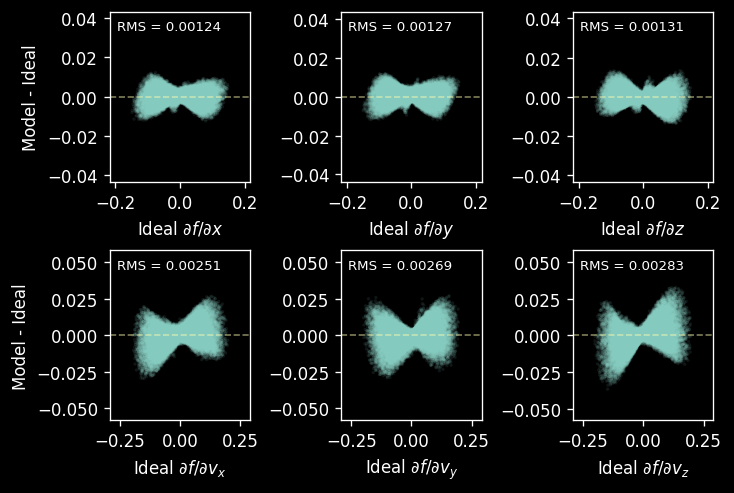

In [67]:
# Scatter plots comparing ideal and learned gradients
fig,ax_arr = plt.subplots(2, 3, figsize=(6,4), constrained_layout=True)
labels = [r'x', r'y', r'z', r'v_x', r'v_y', r'v_z']
for i,ax in enumerate(ax_arr.flatten()):
    delta_grad = flow_grads['df_deta'][:,i]-df_grad_ideal[:,i]
    ax.scatter(
        df_grad_ideal[:,i],
        delta_grad,
        s=4, alpha=0.1, edgecolors='none'
    )
    lim = 2*np.nanpercentile(np.abs(df_grad_ideal[:,i]), 99.5)
    k = 0.2
    ax.axhline(0, c='C1', ls='--', lw=1, alpha=0.5)
    # ax.plot([-lim,lim], [-lim,lim], c='C1', ls='--', lw=1, alpha=0.5)
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-k*lim, k*lim)
    #ax.set_aspect('equal')
    ax.set_xlabel(r'Ideal $\partial f / \partial ' + labels[i] + '$')
    if i % 3 == 0:
        ax.set_ylabel(r'Model - Ideal')
    # Calculate clipped RMS error, by removing top 1% of outliers
    delta_clip_val = np.nanpercentile(np.abs(delta_grad), 99.)
    rms = np.nanstd(delta_grad[np.abs(delta_grad) < delta_clip_val])
    # Display RMS error in top-left of axis
    ax.text(
        0.05, 0.95,
        f'RMS = {rms:.3g}',
        transform=ax.transAxes,
        ha='left', va='top',
        fontsize=8,
        color='w'
        # bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.8, lw=0.5)
    )
plt.show()

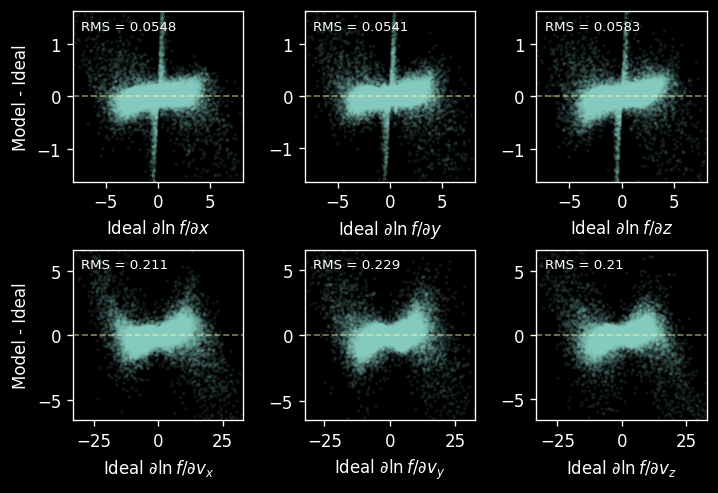

In [70]:
# d(ln DF)/d(eta) version of the above plots, using the chain rule
ln_df_grad_ideal = df_grad_ideal / df_ideal_vals[:,None]
ln_df_grad_model = flow_grads['df_deta'] / flow_grads['f'][:,None]

fig,ax_arr = plt.subplots(2, 3, figsize=(6,4), constrained_layout=True)
labels = [r'x', r'y', r'z', r'v_x', r'v_y', r'v_z']
for i,ax in enumerate(ax_arr.flatten()):
    delta_grad = ln_df_grad_model[:,i]-ln_df_grad_ideal[:,i]
    ax.scatter(
        ln_df_grad_ideal[:,i],
        delta_grad,
        s=4, alpha=0.1, edgecolors='none'
    )
    lim = 2*np.nanpercentile(np.abs(ln_df_grad_ideal[:,i]), 99.5)
    ax.axhline(0, c='C1', ls='--', lw=1, alpha=0.5)
    # ax.plot([-lim,lim], [-lim,lim], c='C1', ls='--', lw=1, alpha=0.5)
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-0.2*lim, 0.2*lim)
    ax.set_box_aspect(1)
    ax.set_xlabel(r'Ideal $\partial \ln f / \partial ' + labels[i] + '$')
    if i % 3 == 0:
        ax.set_ylabel(r'Model - Ideal')
    # Calculate clipped RMS error, by removing top 1% of outliers
    delta_clip_val = np.nanpercentile(np.abs(delta_grad), 99.)
    rms = np.nanstd(delta_grad[np.abs(delta_grad) < delta_clip_val])
    # Display RMS error in top-left of axis
    ax.text(
        0.05, 0.95,
        f'RMS = {rms:.3g}',
        transform=ax.transAxes,
        ha='left', va='top',
        fontsize=8,
        color='w'
        # bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.8, lw=0.5)
    )
plt.show()

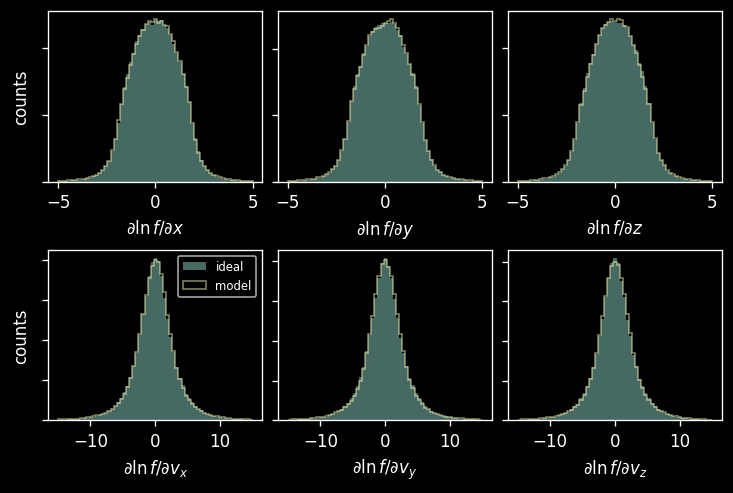

In [17]:
# Plot histograms of the gradients of the logs of the ideal and model DFs
fig,ax_arr = plt.subplots(2, 3, figsize=(6,4), constrained_layout=True)
labels = [r'x', r'y', r'z', r'v_x', r'v_y', r'v_z']
for i,ax in enumerate(ax_arr.flatten()):
    kw = dict(
        bins=np.linspace(-5,5,64) if i < 3 else np.linspace(-15,15,64),
        alpha=0.5
    )
    ax.hist(ln_df_grad_ideal[:,i], label='ideal', histtype='stepfilled', **kw)
    ax.hist(ln_df_grad_model[:,i], label='model', histtype='step', **kw)
    ax.set_xlabel(rf'$\partial \ln f / \partial {labels[i]}$')
    ax.set_yticklabels([])
    if i % 3 == 0:
        ax.set_ylabel('counts')
    if i == 3:
        ax.legend(fontsize=7)
plt.show()

## DF projections

In [ ]:
from plummer_sphere import draw_from_sphere

# Draw random coordinates inside each (r,v) bin
n_samp_per_bin = 32
r_bins = np.logspace(-1, np.log10(r_max), 32)
v_bins = np.linspace(0, np.sqrt(2), 32)

# Extend both r and v bins beyond the edges of the true distribution
r_bins = np.hstack([r_bins, r_bins[-1]*(r_bins[1]/r_bins[0])**np.arange(1,5)])
v_bins = np.hstack([v_bins, v_bins[-1]+(v_bins[1]-v_bins[0])*np.arange(1,5)])

grid_shape = (r_bins.size-1, v_bins.size-1)
u = rng.uniform(size=grid_shape+(n_samp_per_bin,))

r_samp = (
    (r_bins[1:]**3-r_bins[:-1]**3)[:,None,None] * u
    + (r_bins[:-1]**3)[:,None,None]
)**(1/3)
v_samp = (
    (v_bins[1:]**3-v_bins[:-1]**3)[None,:,None] * u
    + (v_bins[:-1]**3)[None,:,None]
)**(1/3)

r_samp.shape = (-1,) # is this flatten?
v_samp.shape = (-1,)

xyz_samp = draw_from_sphere(r_samp.size, rng=rng) * r_samp[:,None]
vv_samp = draw_from_sphere(v_samp.size, rng=rng) * v_samp[:,None]

print(f'Evaluating model & ideal DF at {len(r_samp)} points in (r,v) space.')

# Evaluate model DF at sampled points
lnp_flow = flow_lnp(np.concatenate([xyz_samp, vv_samp], axis=-1))
n_flow = np.exp(lnp_flow)

# Evaluate ideal DF at sampled points
n_ideal = dist_fn.df(xyz_samp, vv_samp)
# Truncate at r_max
n_ideal[r_samp > r_max] = 0.0
# Correct for r_max truncation
n_ideal /= mass_encl

Evaluating model & ideal DF at 39200 points in (r,v) space.


In [50]:
# Reshape back to (n_r_bins, n_v_bins, n_samp_per_bin) and average over samples
s = grid_shape + (n_samp_per_bin,)
n_flow.shape = s
n_ideal.shape = s
n_flow = np.mean(n_flow, axis=-1)
n_ideal = np.mean(n_ideal, axis=-1)

In [51]:
train_data, _ = utils.load_training_data(run_dir / 'data/plummer_sphere_allstars.h5')

In [58]:
# Draw samples from the flow
n_samp_flow = 1024*1024*2
batch_size = 1024*16
n_batches = n_samp_flow // batch_size

eta_samples = []
key = jax.random.key(0)
for i in tqdm(range(n_batches)):
    key, subkey = jax.random.split(key)
    eta_batch = flow_model.sample(subkey, batch_size)
    eta_samples.append(np.array(eta_batch))
eta_samples = np.concatenate(eta_samples, axis=0)

jax.clear_caches()

100%|██████████| 128/128 [04:35<00:00,  2.16s/it]


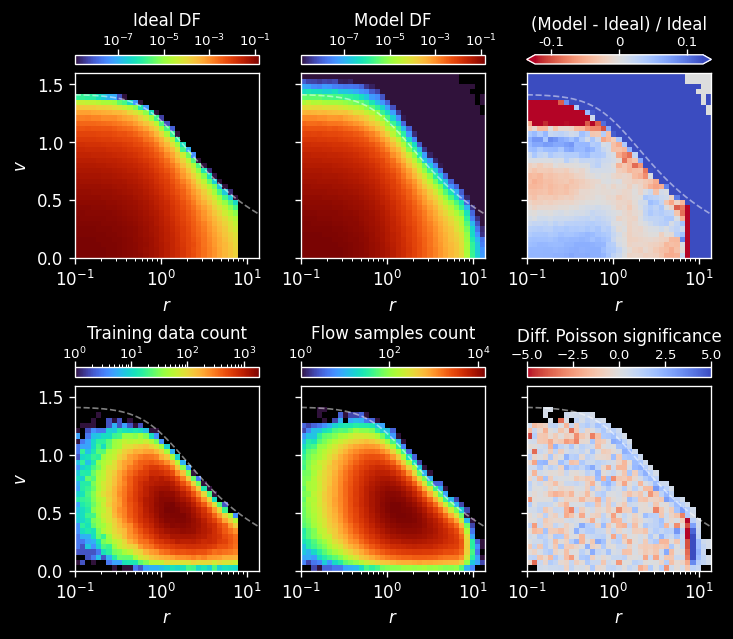

In [64]:
from matplotlib.colors import SymLogNorm

# Plot number density in (r,v) space.
# Use pcolor to deal with log spacing of r bins.
fig,ax_arr = plt.subplots(2, 3, figsize=(6,5.6), layout='compressed')

vmin,vmax = np.percentile(n_ideal[n_ideal > 0], 1.), np.max(n_ideal)
kw = dict(
    cmap='turbo',
    norm=LogNorm(vmin=vmin, vmax=vmax)
)

# Ideal DF
ax = ax_arr[0, 0]
im = ax.pcolormesh(r_bins, v_bins, n_ideal.T, **kw)
cbar = fig.colorbar(im, ax=ax, location='top', label='Ideal DF')
cbar.ax.tick_params(labelsize=8, pad=0)
ax.set_ylabel('$v$')

# Model DF
ax = ax_arr[0, 1]
im = ax.pcolormesh(r_bins, v_bins, n_flow.T, **kw)
cbar = fig.colorbar(im, ax=ax, location='top', label='Model DF')
cbar.ax.tick_params(labelsize=8, pad=0)
ax.set_yticklabels([])

# Difference
ax = ax_arr[0, 2]
# img = 2 * (n_flow - n_ideal) / (n_flow+n_ideal)
img = ((n_flow - n_ideal)/(n_ideal+1e-100))
# img = np.asinh(n_ideal/n_flow - 1)
vmax = 2*np.nanpercentile(np.abs(img), 50.)
kw['cmap'] = 'coolwarm_r'
kw['norm'] = CenteredNorm(halfrange=vmax)
# kw['norm'] = SymLogNorm(linthresh=vmax, linscale=1000, vmin=-10*vmax, vmax=10*vmax)
im = ax.pcolormesh(r_bins, v_bins, img.T, **kw)
cbar = fig.colorbar(
    im, ax=ax,
    location='top',
    label='(Model - Ideal) / Ideal',
    extend='both'
)
cbar.ax.tick_params(labelsize=8, pad=0)
from matplotlib.ticker import FuncFormatter
cbar.formatter = FuncFormatter(lambda x, _: f'{x:.1g}')
cbar.update_ticks()
ax.set_yticklabels([])



n_train, n_sample = len(train_data['eta']), len(eta_samples)
# Training data
ax = ax_arr[1, 0]
r_train = np.linalg.norm(train_data['eta'][:,:3], axis=1)
v_train = np.linalg.norm(train_data['eta'][:,3:], axis=1)
nt, _, _, im = ax.hist2d(
    r_train, v_train,
    bins=[r_bins, v_bins],
    range=[[r_bins[0], r_bins[-1]], [v_bins[0], v_bins[-1]]],
    norm=LogNorm(),
    cmap='turbo'
)
cbar = fig.colorbar(im, ax=ax, location='top', label='Training data count')
cbar.ax.tick_params(labelsize=8, pad=0)
ax.set_ylabel('$v$')

# Model samples
ax = ax_arr[1, 1]
r_sample = np.linalg.norm(eta_samples[:,:3], axis=1)
v_sample = np.linalg.norm(eta_samples[:,3:], axis=1)
ns, _, _, im = ax.hist2d(
    r_sample, v_sample,
    bins=[r_bins, v_bins],
    range=[[r_bins[0], r_bins[-1]], [v_bins[0], v_bins[-1]]],
    norm=LogNorm(),
    cmap='turbo'
)
cbar = fig.colorbar(im, ax=ax, location='top', label='Flow samples count')
cbar.ax.tick_params(labelsize=8, pad=0)
ax.set_yticklabels([])

# Difference
ax = ax_arr[1, 2]
dn = ns/n_sample - nt/n_train
with np.errstate(divide='ignore', invalid='ignore'):
    dn /= np.sqrt(ns * (n_train/n_sample)) / n_train
vmax = 5.

im = ax.pcolormesh(
    r_bins, v_bins, dn.T,
    cmap='coolwarm_r',
    vmin=-vmax, vmax=vmax,
    rasterized=True
)
cbar = fig.colorbar(im, ax=ax, location='top', label='Diff. Poisson significance')
cbar.ax.tick_params(labelsize=8, pad=0)
ax.set_yticklabels([])

# Plot escape velocity curve on each axis
r_plot = np.logspace(np.log10(r_bins[0]), np.log10(r_bins[-1]), 256)
v_esc = np.sqrt(-2*dist_fn.phi(r_plot))
for ax in ax_arr.flatten():
    ax.set_xscale('log')
    ax.set_xlim(r_bins[0], r_bins[-1])
    ax.set_ylim(v_bins[0], v_bins[-1])
    ax.set_aspect('auto')
    ax.set_xlabel('$r$')
    ax.plot(r_plot, v_esc, 'w--', lw=1, alpha=0.5)
    ax.set_box_aspect(1)

plt.show()

## DF tomography

Next, we render tomographic slices of the model DF and compare with the ideal DF. We take slices of constant $z$. To integrate over velocity at each coordinate, we use importance sampling, with the ideal DF as the proposal distribution $Q\left(\vec{v}\right) = p_{\mathrm{ideal}}(\vec{v}\mid\vec{x})$:
$$
  f_{\mathrm{model}}\left(\vec{x}\right) \approx
    \left<
      \frac{
        f_{\mathrm{model}}\left(\vec{x},\vec{v}\right)
      }{
        p_{\mathrm{ideal}}\left(\vec{v}\mid\vec{x}\right)
      }
    \right>_{
      \vec{v} \sim p_{\mathrm{ideal}}\left(\vec{v}\mid\vec{x}\right)
    }
  \, .
$$
The conditional probability $p_{\mathrm{ideal}}(\vec{v}\mid\vec{x})$ can be rewritten as
$$
  p_{\mathrm{ideal}}(\vec{v}\mid\vec{x}) =
    \frac{
      f_{\mathrm{ideal}}\left(\vec{x},\vec{v}\right)
    }{
      \int f_{\mathrm{ideal}}\left(\vec{x},\vec{v}\right) \mathrm{d}^3\vec{v}
    }
  =
    \frac{
      f_{\mathrm{ideal}}\left(\vec{x},\vec{v}\right)
    }{
      f_{\mathrm{ideal}}\left(\vec{x}\right)
    }
  \, .
$$
Plugging this back into the importance sampling equation above,
$$
  f_{\mathrm{model}}\left(\vec{x}\right) \approx
    f_{\mathrm{ideal}}\left(\vec{x}\right)
    \left<
      \frac{
        f_{\mathrm{model}}\left(\vec{x},\vec{v}\right)
      }{
        f_{\mathrm{ideal}}\left(\vec{x},\vec{v}\right)
      }
    \right>_{
      \vec{v} \sim p_{\mathrm{ideal}}\left(\vec{v}\mid\vec{x}\right)
    }
  \, .
$$
For the Plummer sphere, the distribution function and the gravitational potential are self-consistent, so that $f_{\mathrm{ideal}}\left(\vec{x}\right) = \rho_{\mathrm{ideal}}\left(\vec{x}\right)$, where $\rho$ is defined as the gravitational mass. The above formula provides a convenient means of integrating over velocity at a given location $\vec{x}$. The one deficiency of this formula is that the ideal velocity distribution has a sharp cut-off (at the escape velocity), meaning that the integral does not extend beyond this velocity.

In [35]:
from tqdm import tqdm

# Generate a tomographic image of the flow by taking slices of constant z, averaging over velocities
n_frames = 91
n_samples_per_bin = 16
n_pix = 41

z_slices = np.linspace(-r_max, r_max, n_frames)

x_edges = np.linspace(-r_max, r_max, n_pix+1)
x_centers = 0.5 * (x_edges[1:] + x_edges[:-1])
x_grid,y_grid = np.meshgrid(x_edges, x_edges, indexing='ij')

# Empty arrays to hold image slices
img_slices_flow = np.zeros((n_frames,n_pix,n_pix))
img_slices_ideal = np.zeros_like(img_slices_flow)

# Loop over z
for i,z in enumerate(tqdm(z_slices)):
    print(f'Frame {i+1}/{n_frames}, z = {z:.2f}')
    # For each pixel, draw n_samples_per_bin random samples within the pixel
    # and at the given z value.
    # Evaluate the DF at each sample, average over samples to get mean DF in pixel.
    # Store in img_slices[i]

    # Jitter x and y coordinates within each pixel
    xy_samples = rng.uniform(size=(2,n_samples_per_bin,n_pix,n_pix))
    xy_samples *= (x_edges[1] - x_edges[0])
    xy_samples[0,None,:,None] += x_edges[:-1][None,:,None]
    xy_samples[1,None,None,:] += x_edges[:-1][None,None,:]
    xyz_samples = np.stack([
        xy_samples[0],
        xy_samples[1],
        z * np.ones_like(xy_samples[0])
    ], axis=-1)

    # Sample velocities in each pixel
    r_samples = np.linalg.norm(xyz_samples, axis=-1)
    r_samples.shape = (-1,)
    psi = dist_fn.psi(r_samples)
    psi = np.maximum(psi, 0.0)
    # Sample velocities from DF at each radius
    v_samples = np.sqrt(psi) * dist_fn._v_sampler(r_samples.size, rng=rng)
    v_samples = v_samples[:,None] * draw_from_sphere(r_samples.size, rng=rng)
    v_samples.shape = xyz_samples.shape

    eta_samples = np.concatenate([
        xyz_samples.reshape(-1,3),
        v_samples.reshape(-1,3)
    ], axis=-1)

    if i == 0:
        print(f'Using {eta_samples.size:,} coordinate samples per frame.')

    # Ideal ln(p), used for importance sampling calculation
    ideal_rho_samples = np.log(dist_fn.rho(r_samples))
    ideal_df_samples = np.log(dist_fn.df(eta_samples[:,:3], eta_samples[:,3:]))
    ideal_rho_samples.shape = (n_samples_per_bin, n_pix, n_pix)
    ideal_df_samples.shape = (n_samples_per_bin, n_pix, n_pix)

    lnp_samples = np.log(dist_fn.df(eta_samples[:,:3], eta_samples[:,3:]))
    # lnp_samples[r_samples > r_max] = -np.inf
    # lnp_samples -= np.log(m_encl)
    lnp_samples.shape = (n_samples_per_bin, n_pix, n_pix)

    # Importance sampling correction
    # ln_weights = scipy.special.logsumexp(lnp_samples, axis=0)[None] - lnp_samples

    img_slices_ideal[i] = (
        scipy.special.logsumexp(ideal_rho_samples, axis=0)
        - np.log(n_samples_per_bin)
    )

    # Model ln(p)
    model_df_samples = np.array(flow_lnp(eta_samples))
    model_df_samples.shape = (n_samples_per_bin, n_pix, n_pix)
    img_slices_flow[i] = (
        scipy.special.logsumexp(ideal_rho_samples, axis=0)
        + scipy.special.logsumexp(model_df_samples, axis=0)
        - scipy.special.logsumexp(ideal_df_samples, axis=0)
        - np.log(n_samples_per_bin)
    )
    # img_slices_flow[i] = scipy.special.logsumexp(lnp_samples+ln_weights, axis=0) - np.log(n_samples_per_bin)

  0%|          | 0/91 [00:00<?, ?it/s]

Frame 1/91, z = -8.00
Using 161,376 coordinate samples per frame.


  1%|          | 1/91 [00:06<10:04,  6.71s/it]

Frame 2/91, z = -7.82


  2%|▏         | 2/91 [00:11<07:59,  5.39s/it]

...

 98%|█████████▊| 89/91 [06:20<00:08,  4.37s/it]

Frame 90/91, z = 7.82


 99%|█████████▉| 90/91 [06:24<00:04,  4.36s/it]

Frame 91/91, z = 8.00


100%|██████████| 91/91 [06:28<00:00,  4.27s/it]


In [42]:
%matplotlib inline

In [44]:
# Save the image slices as an npz array
np.savez_compressed(
    'plots/frames/plummer_flow_xy_slices.npz',
    img_slices_flow=img_slices_flow.astype('f4'),
    img_slices_ideal=img_slices_ideal.astype('f4')
)

In [45]:
! mkdir -p plots/frames

/disk1/kalda/conda/py311jax_updated/lib/python3.11/pty.py:89: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


In [46]:
# Plot images using imshow, one at a time

import matplotlib.patheffects as patheffects
from matplotlib.ticker import MaxNLocator, AutoMinorLocator

vmax = np.max(img_slices_flow)
# vmin = np.percentile(img_slices, 0.1)
vmin = np.min(img_slices_flow[len(img_slices_flow)//2])

for i in tqdm(range(n_frames)):
    ln_vmax_frame = np.max(img_slices_flow[i])

    fig,ax_arr = plt.subplots(1, 3, figsize=(9,4), constrained_layout=True)

    # Model DF (linear scale)
    ax = ax_arr[0]
    im = ax.imshow(
        np.exp(img_slices_flow[i]).T,
        origin='lower',
        extent=(-r_max,r_max,-r_max,r_max),
        cmap='turbo',
        norm=Normalize(vmin=0., vmax=1.1*np.exp(ln_vmax_frame)),
        interpolation='bicubic'
    )
    ax.set_xlabel('$x$')
    ax.set_ylabel('$y$', labelpad=-7)
    cbar = plt.colorbar(
        im, ax=ax,
        label=r'$\rho_\mathrm{model}$',
        location='top',
        aspect=30,
        pad=0.01
    )
    cbar.ax.tick_params(labelsize=8, pad=0)
    cbar.locator = MaxNLocator(nbins=4)
    cbar.update_ticks()
    ax.text(
        0.03, 0.98,
        f'$z = {z_slices[i]:.2f}$',
        transform=ax.transAxes,
        ha='left', va='top',
        fontsize=9,
        color='w',
        path_effects=[patheffects.withStroke(linewidth=2, foreground='k')]
    )

    # Model DF (log scale)
    ax = ax_arr[1]
    im = ax.imshow(
        img_slices_flow[i].T,
        origin='lower',
        extent=(-r_max,r_max,-r_max,r_max),
        cmap='turbo',
        norm=Normalize(vmin=ln_vmax_frame-15, vmax=ln_vmax_frame+0.5),
        interpolation='bicubic'
    )
    ax.set_xlabel('$x$')
    ax.set_yticklabels([])
    cbar = plt.colorbar(
        im, ax=ax,
        extend='min',
        label=r'$\ln\rho_\mathrm{model}$',
        location='top',
        aspect=30,
        pad=0.01
    )
    cbar.ax.tick_params(labelsize=8, pad=0)
    cbar.locator = MaxNLocator(nbins=4)

    # Difference
    ax = ax_arr[2]
    img = img_slices_flow[i] - img_slices_ideal[i] + np.log(mass_encl)
    im = ax.imshow(
        img.T,
        origin='lower',
        extent=(-r_max,r_max,-r_max,r_max),
        cmap='coolwarm_r',
        norm=CenteredNorm(halfrange=0.3),
        interpolation='bicubic'
    )
    ax.set_xlabel('$x$')
    ax.set_yticklabels([])
    cbar = plt.colorbar(
        im, ax=ax,
        extend='both',
        label=r'$\ln\rho_\mathrm{model} - \ln\rho_\mathrm{ideal}$',
        location='top',
        aspect=30,
        pad=0.01
    )
    cbar.ax.tick_params(labelsize=8, pad=0)

    # Draw circle at radius r_max
    r_max_eff = np.sqrt(r_max**2 - z_slices[i]**2)
    for ax in ax_arr:
        circle = plt.Circle(
            (0, 0),
            r_max_eff,
            color='w',
            fill=False,
            ls='--',
            lw=1,
            alpha=0.5
        )
        ax.add_artist(circle)
        ax.set_aspect('equal')
        ax.set_xlim(-r_max,r_max)
        ax.set_ylim(-r_max,r_max)
        ax.xaxis.set_major_locator(MaxNLocator(5))
        ax.yaxis.set_major_locator(MaxNLocator(5))
        ax.xaxis.set_minor_locator(AutoMinorLocator())
        ax.yaxis.set_minor_locator(AutoMinorLocator())

    # Save figure
    plt.savefig(f'plots/frames/plummer_flow_xy_slices_{i:02d}.png', dpi=200)
    plt.close('all')
    # plt.show()

  0%|          | 0/91 [00:00<?, ?it/s]

100%|██████████| 91/91 [01:38<00:00,  1.08s/it]


In [48]:
# Turn frames into movie using ffmpeg

frame_fn = 'plots/frames/plummer_flow_xy_slices_%02d.png'
movie_fn = 'plots/plummer_flow_z_tomography.mp4'

! ffmpeg -y -r 20 -i {frame_fn} -c:v libx264 -crf 20 -pix_fmt yuv420p -profile:v baseline -movflags +faststart -r 20 {movie_fn}
! du -sh {movie_fn}

/bin/bash: line 1: ffmpeg: command not found
du: cannot access 'plots/plummer_flow_z_tomography.mp4': No such file or directory


In [ ]:
ffmpeg -y -r 20 -i "plots/frames/plummer_flow_xy_slices_%02d.png" -c:v libx264 -crf 20 -pix_fmt yuv420p -profile:v baseline -movflags +faststart -r 20 "plots/plummer_flow_z_tomography.mp4"